<a href="https://colab.research.google.com/github/PrintTrd/DE_practice/blob/main/600526_ThiradaT_SuperAI1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🦐 mini-Hackathon: ข้อมูลการนำเข้า–ส่งออกสินค้าประมงของประเทศไทย
---
Link Dataset: https://www.thackle.or.th/th/dataset/93

| ขั้นตอน | หัวข้อ |
|--------|--------|
| 1️⃣ | Setup & Load Data |
| 2️⃣ | First Look (EDA เบื้องต้น) |
| 3️⃣ | Data Quality & Cleaning |
| 4️⃣ | Advanced EDA & Insights |
| 5️⃣ | Dashboard Preparation |

---
📦 **ข้อมูล:** การนำเข้าและส่งออกสินค้าประมงของประเทศไทย จำแนกตาม ประเทศคู่ค้า ประเภทสินค้า (HS Code) ปริมาณและน้ำหนักสินค้า มูลค่าการค้า เดือนและปีของการค้า

🗂️ **แหล่งที่มา:**
ระบบบัญชีข้อมูลภาครัฐ (Government Open Data)
https://data.go.th/dataset/impexp_product

📐 **ตัวคูณ และหน่วย**: weight (ปริมาณน้ำหนักสินค้า) = * 1,000 กิโลกรัม, price (มูลค่าการค้า) = * 1,000,000 บาท

## 1️⃣ Setup & Load Data

### 📦 ติดตั้งและ Import Libraries

ก่อนเริ่มต้น เราต้อง import library ที่จำเป็นสำหรับการวิเคราะห์ข้อมูลและสร้างกราฟ โดย `pandas` ใช้สำหรับจัดการตาราง, `numpy` สำหรับคำนวณเชิงตัวเลข, `matplotlib` และ `seaborn` สำหรับสร้าง static chart, `plotly` สำหรับ interactive visualization และ `warnings` เพื่อซ่อน warning ที่ไม่จำเป็น การเตรียม environment ที่ดีตั้งแต่ต้นจะช่วยให้ workflow ราบรื่นตลอดทั้ง notebook

In [ ]:
# ติดตั้ง library เพิ่มเติม (ถ้าจำเป็น)
!pip install plotly kaleido -q
!pip install googletrans==4.0.0-rc1

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#ดาวน์โหลดฟอนต์ภาษาไทย (TH Sarabun New)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
#เพิ่มฟอนต์เข้าไปในระบบ
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=16)
sns.set_theme(style="whitegrid", font="TH Sarabun New")

# ตั้งค่า style
plt.rcParams['figure.dpi'] = 120

print('✅ Import สำเร็จ!')

✅ Import สำเร็จ!


### 📂 โหลดข้อมูล
โหลดไฟล์โดยใช้ `encoding='utf-8-sig'` เพื่อรองรับอักขระภาษาไทยและ BOM (Byte Order Mark)แล้วตรวจสอบขนาดข้อมูล และแสดงตัวอย่างแถว เพื่อให้เข้าใจโครงสร้างของ dataset ก่อนลงมือวิเคราะห์

In [ ]:
# Upload ไฟล์ผ่าน Files panel หรือใช้ Google Drive
import os
from google.colab import drive

file_name = 'import_export.csv'
file_path = os.path.join('/content/drive/MyDrive/GoogleColab_Data', file_name)

if not os.path.exists(file_name):
    try:
        drive.mount('/content/drive')
        print("Google Drive mounted. Re-checking file existence.")
        if not os.path.exists(file_path):
            print(f"Error: File still not found at {file_path} after mounting drive. Please check the file path or ensure the file is in MyDrive/GoogleColab_Data.")
        else:
            print("File found after mounting. Loading data...\n")
    except Exception as e:
        print(f"Error mounting Google Drive: {e}. Please ensure you authorize access.")
else:
    print("File found. Loading data directly...\n")
    file_path = file_name
# Read CSV file
df_impexp = pd.read_csv(
    file_path,
    encoding='utf-8-sig'
)
# ตรวจสอบข้อมูลว่ามีกี่แถว, มีค่า Null จำนวนเท่าไร และประเภทข้อมูล (DataType) ของแต่ละคอลัมน์มีอะไรบ้าง
df_impexp.info()

File found. Loading data directly...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42057 entries, 0 to 42056
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year             42057 non-null  int64 
 1   month            42057 non-null  int64 
 2   heading11        42057 non-null  int64 
 3   countryID        42032 non-null  object
 4   countryNameTH    42057 non-null  object
 5   weight           42057 non-null  int64 
 6   quantity         42057 non-null  int64 
 7   price            42057 non-null  int64 
 8   tradeflow        42057 non-null  int64 
 9   productDetailEN  42057 non-null  object
 10  productDetailTH  42057 non-null  object
 11  ETL_DATE         42057 non-null  object
dtypes: int64(7), object(5)
memory usage: 3.9+ MB


ตอนแรกที่อ่านไฟล์ จะพบว่า countryID มี NaN แต่ countryNameTH มีข้อมูลครบ

In [ ]:
# Null Column
df_impexp.isnull().sum()

,0
year,0
month,0
heading11,0
countryID,25
countryNameTH,0
weight,0
quantity,0
price,0
tradeflow,0
productDetailEN,0


In [ ]:
# Find countryNameTH where countryID is NaN
nan_country_names = df_impexp[df_impexp['countryID'].isnull()]['countryNameTH'].unique()
if nan_country_names:
    print(f"CountryNameTH corresponding to NaN in countryID: {', '.join(map(str, nan_country_names))}")
else:
    print("No countryNameTH found corresponding to NaN in countryID.")

CountryNameTH corresponding to NaN in countryID: นามิเบีย


ซึ่งประเทศนามิเบีย มี countryID เป็น "NA" จึงจะปรับเปลี่ยนวิธีการอ่านไฟล์ใหม่ คือใส่ flag **`keep_default_na=False`** แล้วโหลดใหม่

(พอไปค้นหาข้อมูลดูก็รู้ว่า ในอนาคตต้องระวัง จังหวัดน่าน ของประเทศไทยเช่นกัน)

In [ ]:
# Memory Optimization
dtype_dict = {
    'year': 'int16',
    'month': 'int8',
    'heading11': 'str',
    'countryID': 'str',
    'countryNameTH': 'str',
    'weight': 'int32',
    'quantity': 'int32',
    'price': 'int32',
    'tradeflow': 'int8',
    'productDetailEN': 'str',
    'productDetailTH': 'str',
    'ETL_DATE': 'str' # cannot directly parse a column into a datetime object
}
# keep_default_na=False - Prevent from Pandas automatically converts "NA" into NaN
df_impexp = pd.read_csv(
    file_path,
    encoding='utf-8-sig',
    keep_default_na=False,
    dtype=dtype_dict
)

### ภาพรวม และตัวอย่าง
นอกจากแก้ Null Values ที่เกิดจากการแปลงค่าอัตโนมัติของ Pandas แล้ว หลังตั้งค่า dtype ทำให้ memory usage ลดเหลือ 2.6+ MB จาก 3.9+ MB ด้วย

In [ ]:
df_impexp.info()
print('\n📅 ข้อมูลนำเข้า-ส่งออกสินค้าประมง')
print(f'   ➜ จำนวน: {df_impexp.shape[0]:,} แถว | {df_impexp.shape[1]} คอลัมน์')
print(f'   ➜ รายการคอลัมน์: {df_impexp.columns.tolist()}\n')

print('🔍 ตัวอย่างข้อมูล:')
display(df_impexp.head(3))
print('-' * 60)
display(df_impexp.tail(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42057 entries, 0 to 42056
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year             42057 non-null  int16 
 1   month            42057 non-null  int8  
 2   heading11        42057 non-null  object
 3   countryID        42057 non-null  object
 4   countryNameTH    42057 non-null  object
 5   weight           42057 non-null  int32 
 6   quantity         42057 non-null  int32 
 7   price            42057 non-null  int32 
 8   tradeflow        42057 non-null  int8  
 9   productDetailEN  42057 non-null  object
 10  productDetailTH  42057 non-null  object
 11  ETL_DATE         42057 non-null  object
dtypes: int16(1), int32(3), int8(2), object(6)
memory usage: 2.6+ MB

📅 ข้อมูลนำเข้า-ส่งออกสินค้าประมง
   ➜ จำนวน: 42,057 แถว | 12 คอลัมน์
   ➜ รายการคอลัมน์: ['year', 'month', 'heading11', 'countryID', 'countryNameTH', 'weight', 'quantity', 'price', 'tradeflow

,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
0,2568,8,01062000002,BJ,เบนิน,33,90,48080,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
1,2568,8,01062000002,MU,มอริเชียส,10,50,44147,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
2,2568,8,01062000002,BR,บราซิล,8,150,47068,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59


------------------------------------------------------------


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
42054,2568,8,12122930090,LA,ลาว,50,5,6816,2,For seaweeds imported for used in the manufact...,เฉพาะสาหร่ายทะเล นําเข้ามาเพื่อใช้ในอุตสาหกรรม...,12/3/2026 5:59
42055,2568,9,12122930090,LA,ลาว,20,2,2536,2,For seaweeds imported for used in the manufact...,เฉพาะสาหร่ายทะเล นําเข้ามาเพื่อใช้ในอุตสาหกรรม...,12/3/2026 5:59
42056,2568,11,12122930090,LA,ลาว,50,5,6816,2,For seaweeds imported for used in the manufact...,เฉพาะสาหร่ายทะเล นําเข้ามาเพื่อใช้ในอุตสาหกรรม...,12/3/2026 5:59


---
## 2️⃣ First Look — EDA เบื้องต้น

ขั้นตอน Exploratory Data Analysis (EDA) เบื้องต้น คือการสำรวจข้อมูลอย่างรวดเร็วเพื่อให้เข้าใจ "รูปร่าง" ของ dataset ก่อนลงลึก ดูสถิติพื้นฐาน `describe()`, ค่า null / unique / duplicate ในแต่ละคอลัมน์ ซึ่งช่วยให้ตั้งสมมติฐานได้ว่าข้อมูลมีปัญหาอะไร และควรโฟกัสวิเคราะห์ตรงไหน

### Check null

In [ ]:
# ไม่มี Null Values ที่เกิดจากการแปลงค่าอัตโนมัติของ Pandas แล้ว
df_impexp.isnull().sum()

,0
year,0
month,0
heading11,0
countryID,0
countryNameTH,0
weight,0
quantity,0
price,0
tradeflow,0
productDetailEN,0


### Basic statistic

In [ ]:
# ภาพรวมสถิติเบื้องต้น
df_impexp.describe()

,year,month,weight,quantity,price,tradeflow
count,42057.0,42057.000000,4.205700e+04,4.205700e+04,4.205700e+04,42057.000000
mean,2568.0,6.481109,8.877408e+04,2.158427e+05,8.930086e+06,1.685237
std,0.0,3.443259,4.523216e+05,1.069296e+07,4.082484e+07,0.464427
min,2568.0,1.000000,0.000000e+00,-1.919242e+09,0.000000e+00,1.000000
25%,2568.0,3.000000,8.700000e+01,2.150000e+02,4.400500e+04,1.000000
50%,2568.0,6.000000,2.700000e+03,3.385000e+03,5.541010e+05,2.000000
75%,2568.0,9.000000,2.600000e+04,3.740000e+04,3.534184e+06,2.000000
max,2568.0,12.000000,1.868457e+07,6.794786e+08,1.157586e+09,2.000000


- ยืนยันว่าข้อมูลทั้งหมดมาจากตลอดปี พ.ศ. 2568
- weight กับ price มีค่าต่ำสุดเป็น 0
- quantity (จำนวนสินค้า) ค่าต่ำสุดติดลบ และน่าจะมี 0 ด้วย

### Check unique

In [ ]:
# Check unique values for all columns
for column in df_impexp.columns:
    unique_values = df_impexp[column].unique()
    unique_counts = len(unique_values)
    # Print unique values for all columns, limiting display top 20 for high number of members
    preview = ', '.join(map(str, unique_values[:20]))
    suffix = ', ...' if unique_counts > 100 else ''

    print(f"Column '{column}' — {unique_counts} distinct\n  {preview}{suffix}\n")

Column 'year' — 1 distinct
  2568

Column 'month' — 12 distinct
  8, 9, 1, 2, 3, 4, 5, 6, 11, 12, 7, 10

Column 'heading11' — 448 distinct
  01062000002, 01062000003, 01062000005, 01069000001, 02085000001, 02085000003, 02089010000, 02109300000, 03011191000, 03011192000, 03011193000, 03011195000, 03011910000, 03019200000, 03019911000, 03019919000, 03019929000, 03019941001, 03019941002, 03019942000, ...

Column 'countryID' — 197 distinct
  BJ, MU, BR, EG, KE, IT, SG, SC, ZM, ET, QA, US, SR, ZA, MX, MV, NP, JO, UG, BH, ...

Column 'countryNameTH' — 197 distinct
  เบนิน, มอริเชียส, บราซิล, อียิปต์, เคนยา, อิตาลี, สิงคโปร์, เซเชลส์, แซมเบีย, เอธิโอเปีย, กาตาร์, สหรัฐอเมริกา, Suriname, แอฟริกาใต้, เม็กซิโก, มัลดีฟส์, เนปาล, จอร์แดน, อูกานดา, บาห์เรน, ...

Column 'weight' — 17236 distinct
  33, 10, 8, 315, 49, 2, 5, 200, 25, 45, 20, 420, 380, 7, 650, 70, 3, 450, 30, 1, ...

Column 'quantity' — 17478 distinct
  90, 50, 150, 100, 200, 120, 2, 20, 60, 450, 80, 70, 49, 12, 26, 106, 1556, 4, 52, 1

- tradeflow	คือ ประเภทการค้า (1 = Import, 2 = Export) มี 2 รหัสถูกต้อง
- productDetailEN มีค่าแปลกๆ เช่น (blank), #NAME?

### Negative value

In [ ]:
# List rows with negative quantity
display(df_impexp[df_impexp['quantity'] < 0])

,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
6863,2568,5,03034400000,NR,นาอูรู,32909,-1919241546,3009731,1,Bigeyes tunas(Thunnus obesus) excluding livers...,ปลาบิกอายทูนา แช่เย็นจนแข็ง ไม่รวมตับและไข่(Bi...,12/3/2026 5:59


- ลองสมมติฐานว่าอาจเผลอใส่เครื่องหมายลบเข้าไปในช่องจำนวน แต่ก็คิดว่า น้ำหนักและราคา ต่อตัวของปลา Bigeyes tunas จะน้อยเกินไป -> ดังนั้นจะตัดข้อมูลแถวนี้ทิ้งแทนการแปลงเป็นค่าบวก

### Zero-value anomalies

In [ ]:
# Column ใด column หนึ่งใน weight, quantity, price เป็น 0
zero_mask = (df_impexp['weight'] == 0) | (df_impexp['quantity'] == 0) | (df_impexp['price'] == 0)
print(f"มีข้อมูลเป็น 0 ทั้งหมด {len(df_impexp[zero_mask])} แถว")

มีข้อมูลเป็น 0 ทั้งหมด 474 แถว


In [ ]:
df_zeros = df_impexp[zero_mask]

# Use .query() to find each condition
all_zero        = df_zeros.query('weight == 0 and quantity == 0 and price == 0')
zero_weight     = df_zeros.query('weight == 0 and quantity != 0 and price != 0')
zero_qty        = df_zeros.query('quantity == 0 and weight != 0 and price != 0')
zero_price      = df_zeros.query('price == 0 and weight != 0 and quantity != 0')
weight_only     = df_zeros.query('quantity == 0 and price == 0 and weight != 0')
qty_only        = df_zeros.query('weight == 0 and price == 0 and quantity != 0')
price_only      = df_zeros.query('weight == 0 and quantity == 0 and price != 0')

conditions = {
    'All zero': all_zero,
    'No weight (q & p ≠ 0)': zero_weight,
    'No qty (w & p ≠ 0)': zero_qty,
    'No price (w & q ≠ 0)': zero_price,
    'Weight only (q & p = 0)': weight_only,
    'Qty only (w & p = 0)': qty_only,
    'Price only (w & q = 0)': price_only,
}

# Sanity check — all rows must be covered exactly once
total_covered = sum(len(v) for v in conditions.values())
print(f"df_zeros:      {len(df_zeros)} rows")
print(f"Total covered: {total_covered} rows")
print(f"Uncategorised: {len(df_zeros) - total_covered} rows\n")
for name, df in conditions.items():
    print(f"  {name:<30} {len(df):>6} rows")

df_zeros:      474 rows
Total covered: 474 rows
Uncategorised: 0 rows

  All zero                            1 rows
  No weight (q & p ≠ 0)             361 rows
  No qty (w & p ≠ 0)                  0 rows
  No price (w & q ≠ 0)               11 rows
  Weight only (q & p = 0)             0 rows
  Qty only (w & p = 0)                0 rows
  Price only (w & q = 0)            101 rows


สรุปเป็นแผนภาพ ข้อมูลที่ค่าเป็น 0 ได้ดังนี้

In [ ]:
# Data preparation for Plotly
labels = [key for key, values in conditions.items() if len(values) > 0]
sizes = [len(values) for values in conditions.values() if len(values) > 0]

# Create a horizontal bar
fig = px.bar(
    x=sizes,
    y=labels,
    orientation='h',
    title=f'<b>Zero-value anomalies ({len(df_zeros)} / {len(df_impexp)} rows)</b>',
    color=labels, # Color bars by label for distinction
    color_discrete_sequence=px.colors.qualitative.Pastel,
    height=400,
    width=950,
    labels={'x': 'Number of Rows', 'y': 'Anomaly Case'}
)
# Display count number on bars
fig.update_traces(texttemplate='%{x}', textposition='outside')
fig.update_layout(
    title_x=0.5, # Center the title
    yaxis={'categoryorder':'total ascending', 'tickfont': {'weight': 'bold'}} # Order bars by size and make labels bold
)
fig.show()

In [ ]:
## List rows where weight, quantity, and price are all set to 0
display(all_zero)

,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
11727,2568,9,03061600000,AU,ออสเตรเลีย,0,0,0,2,Cold-water shrimps and prawns (Pandalus spp. ...,กุ้งน้ำเย็น แช่เย็นจนแข็ง,12/3/2026 5:59


- All zero: จะตัดทิ้งเลย
- No price: มีจำนวน และน้ำหนัก แต่ไม่ถูกคิดราคา
โดยในที่นี้จะตีความว่าอาจได้รับมาจากผลประโยชน์ตามสัญญา หรือความร่วมมือของโครงการใดๆ -> จะเก็บไว้
- Price only: คาดว่าไม่ทราบข้อมูลจำนวน และน้ำหนัก -> หาข้อมูลจาก product ที่มีข้อมูลมาเฉลี่ยใส่ก่อน (ถ้าเจอ)
- No weight: สมมติฐานได้ว่าน้ำหนักอาจไม่ถึง 1,000 กิโลกรัม หรือไม่ทราบข้อมูลน้ำหนัก แต่มีจำนวน และราคา -> หาข้อมูลจาก product ที่มีข้อมูลมาเฉลี่ยใส่ก่อน (ถ้าเจอ)

### Check duplicated

In [ ]:
# Check target duplicated rows that will drop
duplicates = df_impexp[df_impexp.duplicated()]
display(duplicates)
print(f"\nมีข้อมูลซ้ำ {len(duplicates)} แถว")

,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
22236,2568,2,16041419000,CU,คิวบา,14400,1200,1929660,2,#NAME?,ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรร...,12/3/2026 5:59
23891,2568,12,16041419000,HK,ฮ่องกง,1,1,32,2,#NAME?,ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรร...,12/3/2026 5:59
30084,2568,4,16055490000,HK,ฮ่องกง,3,1,40,2,Other,ปลาหมึกกระดองและปลาหมึกกล้วยอื่น ๆ ที่ไม่บรรจุ...,12/3/2026 5:59
30193,2568,1,16055490000,HK,ฮ่องกง,7,1,82,2,Other,ปลาหมึกกระดองและปลาหมึกกล้วยอื่น ๆ ที่ไม่บรรจุ...,12/3/2026 5:59
40958,2568,8,16051014090,HK,ฮ่องกง,1,1,128,2,Other,ปู อื่น ๆ,12/3/2026 5:59



มีข้อมูลซ้ำ 5 แถว


---
## 3️⃣ Data Quality & Cleaning 🧹

ก่อนวิเคราะห์จริง เราต้องทำความสะอาดข้อมูลก่อน ขั้นตอนนี้ครอบคลุมการ

1. ลบแถวซ้ำ
2. ลบแถวที่มี weight, quantity และ price เป็น 0 ทั้ง 3 ตัว
3. แปลง quantity ค่าติดลบ ให้เป็นค่าบวก
4. เช็คและเติม productDetailEN ตาม productDetailTH
5. จัดการกรณี Price only (weight & quantity = 0) และ No weight โดยหาข้อมูลจาก productDetailTH ที่มีข้อมูลราคามาเฉลี่ยใส่ก่อนดูก่อน ถ้าไม่ได้จริง ๆ ค่อยตัดแถวนั้นทิ้ง
6. แปลงชนิดข้อมูล `ETL_DATE` จาก object เป็น datetime
7. เช็คผลรวม ดูสรุปข้อมูลอีกครั้ง

In [ ]:
# Copy dataframe
df_cleaning = df_impexp.copy()

### 1. Drop duplicates

In [ ]:
print(f"DataFrame before drop duplicates: {len(df_cleaning):,} rows")
print(f"Have duplicates {len(df_cleaning[df_cleaning.duplicated()])} rows to drop")
# Drop duplicates
df_cleaning = df_cleaning.drop_duplicates()
print("-- Drop duplicates --")
# Check duplicate again
print(f"Remaining duplicates {len(df_cleaning[df_cleaning.duplicated()])} row(s)")
print(f"DataFrame after drop duplicates: {len(df_cleaning):,} rows")

DataFrame before drop duplicates: 42,057 rows
Have duplicates 5 rows to drop
-- Drop duplicates --
Remaining duplicates 0 row(s)
DataFrame after drop duplicates: 42,052 rows


### 2. Drop row where weight, quantity, and price are all set to 0

In [ ]:
print(f"Before drop all_zero: {len(df_cleaning):,} rows")
# Drop all_zero row
df_cleaning = df_cleaning.drop(all_zero.index)
print(f"After drop all_zero: {len(df_cleaning):,} rows")

Before drop all_zero: 42,052 rows
After drop all_zero: 42,051 rows


### 3. Drop negative `quantity` values

In [ ]:
print(f"Before drop negative: {len(df_cleaning):,} rows")
# Drop negative quantity rows by their index
df_cleaning = df_cleaning.drop(df_cleaning[df_cleaning['quantity'] < 0].index)
print("-- Negative 'quantity' rows have been dropped --")
print(f"After drop negative: {len(df_cleaning):,} rows")

Before drop negative: 42,051 rows
-- Negative 'quantity' rows have been dropped --
After drop negative: 42,050 rows


### 4. productDetail
เช็คค่าแปลก ๆ หรือดูจำนวน garbage ก่อนเติม `productDetailEN` ตาม `productDetailTH`

In [ ]:
print(df_cleaning['productDetailEN'].value_counts().head(10))
print()
print(df_cleaning['productDetailTH'].value_counts().head(10))

productDetailEN
(blank)                                                                                    8689
Other                                                                                      8341
#NAME?                                                                                     7584
Fish sauce                                                                                 1007
Surimi meat                                                                                 601
Yellowfin tunas(Thunnus albacares) excluding livers and roes frozen                         563
Oscars (Astonotus ocellatus)                                                                553
Sardines sardinella and brisling or sprats prepared or preserved in airtight containers     494
Squid frozen                                                                                483
Live                                                                                        431
Name: count, dtype: int6

In [ ]:
# Check productDetailEN and productDetailTH
invalid_values = ['(blank)', '#name?']
maskEN = df_cleaning['productDetailEN'].str.strip().str.lower().isin(invalid_values)
maskTH = df_cleaning['productDetailTH'].str.strip().isin(invalid_values)

total = len(df_cleaning)
invalid_count_EN = maskEN.sum()
invalid_count_TH = maskTH.sum()

print(f"Total rows:        {total}")
print(f"Invalid EN rows:   {invalid_count_EN} ({invalid_count_EN/total*100:.1f}%)")
print(f"Invalid TH rows:   {invalid_count_TH} ({invalid_count_TH/total*100:.1f}%)")

Total rows:        42050
Invalid EN rows:   16273 (38.7%)
Invalid TH rows:   34 (0.1%)


In [ ]:
print(f"ในแถวที่มีปัญหาใน productDetailEN มีค่า unique ฝั่ง productDetailTH อยู่ {df_cleaning[maskEN]['productDetailTH'].nunique()}")
# display(df_cleaning[maskEN]['productDetailTH'].unique())
print(f"ในแถวที่มีปัญหาใน productDetailTH มีค่า unique ฝั่ง productDetailEN อยู่ {df_cleaning[maskTH]['productDetailEN'].nunique()}")
display(df_cleaning[maskTH]['productDetailEN'].unique())

ในแถวที่มีปัญหาใน productDetailEN มีค่า unique ฝั่ง productDetailTH อยู่ 162
ในแถวที่มีปัญหาใน productDetailTH มีค่า unique ฝั่ง productDetailEN อยู่ 1


array(['(blank)'], dtype=object)

แสดงว่า Invalid TH rows มี productDetailEN เป็น (blank) เช่นกัน

In [ ]:
# เช็คอีกรอบว่าข้อมูลส่วนอื่นมีประโยชน์อยู่หรือไม่ จะได้ยังไม่ตัดทิ้ง
display(df_cleaning[maskTH])

,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
5381,2568,8,03032900000,VN,เวียดนาม,3728,3728,589078,1,(blank),(blank),12/3/2026 5:59
5382,2568,10,03032900000,VN,เวียดนาม,22268,22268,1419738,1,(blank),(blank),12/3/2026 5:59
5383,2568,1,03032900000,VN,เวียดนาม,4840,4840,663440,1,(blank),(blank),12/3/2026 5:59
5384,2568,3,03032900000,VN,เวียดนาม,16100,16100,1878552,1,(blank),(blank),12/3/2026 5:59
5385,2568,5,03032900000,VN,เวียดนาม,5814,5814,912720,1,(blank),(blank),12/3/2026 5:59
5386,2568,6,03032900000,VN,เวียดนาม,2268,2268,350874,1,(blank),(blank),12/3/2026 5:59
5387,2568,11,03032900000,VN,เวียดนาม,1896,1896,314496,1,(blank),(blank),12/3/2026 5:59
5388,2568,1,03032900000,BH,บาห์เรน,5,5,798,2,(blank),(blank),12/3/2026 5:59
5389,2568,1,03032900000,US,สหรัฐอเมริกา,7987,5527,1603207,2,(blank),(blank),12/3/2026 5:59
5390,2568,1,03032900000,CA,แคนาดา,3645,3645,442438,2,(blank),(blank),12/3/2026 5:59


#### แปลง (blank) เป็น Other/อื่น ๆ
ที่ (blank) ทั้ง productDetailEN และ productDetailTH มีข้อมูลส่วนอื่นเป็นประโยชน์อยู่ จึงจะเปลี่ยนให้เป็น Other/อื่น ๆ


In [ ]:
# EN invalid → 'Other' where TH is 'อื่น ๆ'
mask_other = maskEN & (df_cleaning['productDetailTH'].str.strip() == 'อื่น ๆ')
df_cleaning.loc[mask_other, 'productDetailEN'] = 'Other'

# both EN and TH are '(blank)' → replace both
mask_both_blank = (maskEN & maskTH)
df_cleaning.loc[mask_both_blank, 'productDetailEN'] = 'Other'
df_cleaning.loc[mask_both_blank, 'productDetailTH'] = 'อื่น ๆ'

print(f"EN invalid → 'Other' (TH = อื่น ๆ): {mask_other.sum()} rows")
print(f"Both blank → replaced: {mask_both_blank.sum()} rows")

EN invalid → 'Other' (TH = อื่น ๆ): 22 rows
Both blank → replaced: 34 rows


#### 🗺️ **Translate mapping**
นอกนั้นจะแปลจาก productDetailTH ไปใส่ productDetailEN ด้วย googletrans

1.  หา unique `productDetailTH` values ที่ `productDetailEN` ยัง invalid อยู่
2.  แปลเฉพาะค่า `productDetailTH` ที่ไม่ซ้ำกันจากแถวที่ `productDetailEN` ยัง `invalid` แทนการเรียก `translator.translate` สำหรับแต่ละแถวโดยตรง จากนั้นสร้าง mapping dictionary
3.  ใช้ mapping dictionary ในการอัปเดตค่าในคอลัมน์ `productDetailEN`
4.  Verify the translation results

In [ ]:
from googletrans import Translator

# Create Translator object
translator = Translator()

# Identify rows where productDetailEN is still invalid
new_maskEN = df_cleaning['productDetailEN'].str.strip().str.lower().isin(invalid_values)
# Get unique productDetailTH values from these rows that need translation
unique_th_to_translate = df_cleaning[new_maskEN & (df_cleaning['productDetailTH'].str.strip() != 'อื่น ๆ')]['productDetailTH'].unique()
print(f'Found {len(unique_th_to_translate)} unique productDetailTH values to translate.')

# Create a translation mapping dictionary
translation_map = {}
for th_text in unique_th_to_translate:
    try:
        # Translate and store in map
        translated_text = translator.translate(th_text, dest='en').text
        translation_map[th_text] = translated_text
    except Exception as e:
        print(f"Error translating '{th_text}': {e}")
        translation_map[th_text] = th_text # Fallback to original if translation fails

print(f'Successfully translated {len(translation_map)} unique values.')

# Apply the translation map to update productDetailEN
# Only apply where productDetailEN is currently invalid and productDetailTH is in our map

# Create a temporary Series for mapping
mapped_values = df_cleaning['productDetailTH'].map(translation_map)

# Update df_cleaning['productDetailEN'] only where new_maskEN is True
update_condition = new_maskEN & df_cleaning['productDetailTH'].isin(translation_map.keys())
df_cleaning.loc[update_condition, 'productDetailEN'] = mapped_values[update_condition]

print('productDetailEN updated using translation map.')

Found 160 unique productDetailTH values to translate.
Successfully translated 160 unique values.
productDetailEN updated using translation map.


In [ ]:
# Check productDetailEN and productDetailTH again
cleaned_maskEN = df_cleaning['productDetailEN'].str.strip().str.lower().isin(invalid_values)
cleaned_maskTH = df_cleaning['productDetailTH'].str.strip().isin(invalid_values)

new_invalid_count_EN = cleaned_maskEN.sum()
new_invalid_count_TH = cleaned_maskTH.sum()

print(f"Total rows: {total}")
print(f"new_invalid EN rows: {new_invalid_count_EN} ({new_invalid_count_EN/total*100:.1f}%)")
print(f"new_invalid TH rows: {new_invalid_count_TH} ({new_invalid_count_TH/total*100:.1f}%)")

Total rows: 42050
new_invalid EN rows: 0 (0.0%)
new_invalid TH rows: 0 (0.0%)


### 5. Price only & No weight case

In [ ]:
# Copy dataframe
df_imputing = df_cleaning.copy()

In [ ]:
# 1. Indices to impute
price_only_idx = conditions['Price only (w & q = 0)'].index
no_weight_idx = conditions['No weight (q & p ≠ 0)'].index

# 2. Compute ratios from valid rows only (guarantees all metrics > 0)
valid_data = df_imputing.query('weight > 0 and quantity > 0 and price > 0')
grouped_valid = valid_data.groupby('heading11')
ratios = pd.DataFrame({
    'w_per_p': grouped_valid.apply(lambda x: x['weight'].sum() / x['price'].sum()),
    'q_per_p': grouped_valid.apply(lambda x: x['quantity'].sum() / x['price'].sum()),
    'w_per_q': grouped_valid.apply(lambda x: x['weight'].sum() / x['quantity'].sum()),
}).replace(0, pd.NA) # turns any zero-sum ratio into NaN instead of causing a divide-by-zero

# 3. Impute
def impute(idx, col, ratio_col, driver_col):
    df = df_imputing.loc[idx].join(ratios[[ratio_col]], on='heading11')
    computed = (df[driver_col] * df[ratio_col]).dropna().round()
    df_imputing.loc[computed.index, col] = computed

impute(price_only_idx, 'weight', 'w_per_p', 'price')
impute(price_only_idx, 'quantity', 'q_per_p', 'price')
impute(no_weight_idx, 'weight', 'w_per_q', 'quantity')

# 4. Summary and Verification
def verify(label, idx, check_expr, success_expr):
    total    = len(idx)
    updated_df = df_imputing.loc[idx].query(success_expr)
    updated  = len(updated_df)
    remaining = df_imputing.loc[idx].query(check_expr)
    print(f"\n[{label}]  updated: {updated}/{total}  |  still zero: {len(remaining)}")
    print(f"➜ Updated '{label}' case example:")
    display(updated_df.head(2))
    if not remaining.empty:
        print(f"➜ Remaining '{label}' case example:")
        display(remaining.head(2))

verify('Price only', price_only_idx, 'weight == 0 and quantity == 0', 'weight > 0 and quantity > 0')
verify('No weight', no_weight_idx, 'weight == 0', 'weight > 0')


[Price only]  updated: 68/101  |  still zero: 26
➜ Updated 'Price only' case example:


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
2087,2568,8,03019200000,JP,ญี่ปุ่น,1,1,157,1,Atlantic and Pacific bluefin tunas (Thunnus th...,ปลาแอตแลนติกบลูฟินทูนาและปลาแปซิฟิกบลูฟินทูนาม...,12/3/2026 5:59
3230,2568,12,03024200000,JP,ญี่ปุ่น,2,2,703,1,"Anchovies, fresh, chilled",ปลาแอนโชวี สด แช่เย็น,12/3/2026 5:59


➜ Remaining 'Price only' case example:


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
2092,2568,9,03019200000,JP,ญี่ปุ่น,0,0,85,1,Atlantic and Pacific bluefin tunas (Thunnus th...,ปลาแอตแลนติกบลูฟินทูนาและปลาแปซิฟิกบลูฟินทูนาม...,12/3/2026 5:59
3220,2568,9,03024200000,JP,ญี่ปุ่น,0,0,179,1,"Anchovies, fresh, chilled",ปลาแอนโชวี สด แช่เย็น,12/3/2026 5:59



[No weight]  updated: 303/361  |  still zero: 58
➜ Updated 'No weight' case example:


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
31,2568,12,01062000002,US,สหรัฐอเมริกา,2,4,57067,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
76,2568,12,01062000003,MV,มัลดีฟส์,18,30,1177,2,Taiwan snapping turtles,ตะพาบน้ำไต้หวันมีชีวิต,12/3/2026 5:59


➜ Remaining 'No weight' case example:


,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
176,2568,8,02109300000,KR,เกาหลีใต้,0,1,32,2,Meat and other edible parts of reptiles are sa...,เนื้อและส่วนอื่นที่บริโภคได้ของสัตว์เลื้อยคลาน...,12/3/2026 5:59
184,2568,11,02109300000,KR,เกาหลีใต้,0,1,32,2,Meat and other edible parts of reptiles are sa...,เนื้อและส่วนอื่นที่บริโภคได้ของสัตว์เลื้อยคลาน...,12/3/2026 5:59


รับได้ถ้าเคส [No weight] จะคงเป็น 0 ไว้เพราะไม่รู้ค่า แต่ [Price only] คิดว่าควร drop ที่เหลือทิ้งไป

In [ ]:
print(f"Dataframe size before dropping: {len(df_imputing):,} rows")
# 5. Drop remaining rows that couldn't be imputed
remaining_to_drop = df_imputing.loc[price_only_idx].query('weight == 0 and quantity == 0').index
print(f"Rows to be dropped: {len(remaining_to_drop)}")
df_imputing = df_imputing.drop(index=remaining_to_drop)
print(f"Dataframe size after dropping remaining 'Price only' case: {len(df_imputing):,} rows")

Dataframe size before dropping: 42,050 rows
Rows to be dropped: 26
Dataframe size after dropping remaining 'Price only' case: 42,024 rows


In [ ]:
# Replace dataframe
df_cleaning = df_imputing.copy()

### 6. Convert `ETL_DATE` type from object to datetime

In [ ]:
# แปลงข้อมูลจาก object เป็น datetime
df_cleaning['ETL_DATE'] = pd.to_datetime(df_cleaning['ETL_DATE'], format='%d/%m/%Y %H:%M')

df_cleaning.info()
display(df_cleaning['ETL_DATE'].head())

<class 'pandas.core.frame.DataFrame'>
Index: 42024 entries, 0 to 42056
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   year             42024 non-null  int16         
 1   month            42024 non-null  int8          
 2   heading11        42024 non-null  object        
 3   countryID        42024 non-null  object        
 4   countryNameTH    42024 non-null  object        
 5   weight           42024 non-null  int32         
 6   quantity         42024 non-null  int32         
 7   price            42024 non-null  int32         
 8   tradeflow        42024 non-null  int8          
 9   productDetailEN  42024 non-null  object        
 10  productDetailTH  42024 non-null  object        
 11  ETL_DATE         42024 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(3), int8(2), object(5)
memory usage: 2.9+ MB


,ETL_DATE
0,2026-03-12 05:59:00
1,2026-03-12 05:59:00
2,2026-03-12 05:59:00
3,2026-03-12 05:59:00
4,2026-03-12 05:59:00


### 7. Check Total

In [ ]:
# Check basic statistic again
df_cleaning.describe()

,year,month,weight,quantity,price,tradeflow,ETL_DATE
count,42024.0,42024.000000,4.202400e+04,4.202400e+04,4.202400e+04,42024.000000,42024
mean,2568.0,6.480749,8.884714e+04,2.616823e+05,8.936981e+06,1.685251,2026-03-12 05:58:59.999999488
min,2568.0,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,2026-03-12 05:59:00
25%,2568.0,3.000000,9.000000e+01,2.180000e+02,4.430825e+04,1.000000,2026-03-12 05:59:00
50%,2568.0,6.000000,2.726000e+03,3.400000e+03,5.566785e+05,2.000000,2026-03-12 05:59:00
75%,2568.0,9.000000,2.601750e+04,3.746700e+04,3.540652e+06,2.000000,2026-03-12 05:59:00
max,2568.0,12.000000,1.868457e+07,6.794786e+08,1.157586e+09,2.000000,2026-03-12 05:59:00
std,0.0,3.443136,4.524918e+05,5.172354e+06,4.084012e+07,0.464421,NaN


In [ ]:
total_weight = df_cleaning['weight'].sum()
print(f'⚖️ น้ำหนักสินค้า (Total weight) ทั้งหมด {total_weight:,} x 1,000 กิโลกรัม:')
weight_by_tradeflow = df_cleaning.groupby('tradeflow')['weight'].sum()
print(f"   ➜ Import (tradeflow=1): {weight_by_tradeflow.get(1, 0):,} x 1,000 กิโลกรัม")
print(f"   ➜ Export (tradeflow=2): {weight_by_tradeflow.get(2, 0):,} x 1,000 กิโลกรัม")
print('=' * 60)
total_quantity = df_cleaning['quantity'].sum()
print(f'📋 จำนวนสินค้า (Total quantity) ทั้งหมด {total_quantity:,} รายการ')
print('=' * 60)
total_price = df_cleaning['price'].sum()
print(f'💰 มูลค่ารวมการค้า (Total Price) ทั้งหมด {total_price:,.2f} ล้านบาท:')
price_by_tradeflow = df_cleaning.groupby('tradeflow')['price'].sum()

import_price = price_by_tradeflow.get(1, 0)
export_price = price_by_tradeflow.get(2, 0)
import_pct = (import_price / total_price) * 100
export_pct = (export_price / total_price) * 100
trade_balance = export_price - import_price

print(f"   ➜ Import (tradeflow=1): {import_price:,.2f} ล้านบาท ({import_pct:.2f}%)")
print(f"   ➜ Export (tradeflow=2): {export_price:,.2f} ล้านบาท ({export_pct:.2f}%)")
print('-' * 30)
print(f"⚖️ ดุลการค้าสุทธิ (Trade Balance): {trade_balance:,.2f} ล้านบาท {'(ได้เปรียบ)' if trade_balance > 0 else '(เสียเปรียบ)'}")

⚖️ น้ำหนักสินค้า (Total weight) ทั้งหมด 3,733,712,071 x 1,000 กิโลกรัม:
   ➜ Import (tradeflow=1): 2,062,891,181 x 1,000 กิโลกรัม
   ➜ Export (tradeflow=2): 1,670,820,890 x 1,000 กิโลกรัม
📋 จำนวนสินค้า (Total quantity) ทั้งหมด 10,996,938,822 รายการ
💰 มูลค่ารวมการค้า (Total Price) ทั้งหมด 375,567,673,260.00 ล้านบาท:
   ➜ Import (tradeflow=1): 152,446,602,722.00 ล้านบาท (40.59%)
   ➜ Export (tradeflow=2): 223,121,070,538.00 ล้านบาท (59.41%)
------------------------------
⚖️ ดุลการค้าสุทธิ (Trade Balance): 70,674,467,816.00 ล้านบาท (ได้เปรียบ)


In [ ]:
# Define cleaned_df from the final state of df_cleaning
cleaned_df = df_cleaning.copy()
print("✅ cleaned_df is now ready for analysis.")

✅ cleaned_df is now ready for analysis.


---
## 4️⃣ Advanced EDA & Insights 🔬

### 4.1 🗺️ ตลาดส่งออกสินค้าประมงของไทยอยู่ที่ไหน?
Major Trading Partners
- ประเทศใดเป็น ตลาดส่งออกสินค้าประมงสำคัญของไทย
- ประเทศใดเป็น แหล่งนำเข้าสัตว์น้ำหลักของไทย
- ประเทศใดที่ไทย เกินดุลหรือขาดดุลการค้า ด้านสินค้าประมงอย่างชัดเจน

In [ ]:
trade_data = cleaned_df.copy()

# Group by countryID and countryNameTH to keep both for plotting
imports_by_country = trade_data[trade_data['tradeflow'] == 1].groupby(['countryID', 'countryNameTH'])['price'].sum().reset_index()
exports_by_country = trade_data[trade_data['tradeflow'] == 2].groupby(['countryID', 'countryNameTH'])['price'].sum().reset_index()

# Merge exports and imports into a single DataFrame
trade_summary = pd.merge(exports_by_country, imports_by_country, on=['countryID', 'countryNameTH'], how='outer', suffixes=('_Export', '_Import')).fillna(0)

trade_summary = trade_summary.rename(columns={'price_Export': 'Export_Value', 'price_Import': 'Import_Value'})

# Calculate Trade Balance
trade_summary['Trade_Balance'] = trade_summary['Export_Value'] - trade_summary['Import_Value']

display(trade_summary.describe())
display(trade_summary.info())


,Export_Value,Import_Value,Trade_Balance
count,1.970000e+02,1.970000e+02,1.970000e+02
mean,1.132594e+09,7.738406e+08,3.587536e+08
std,4.609103e+09,2.461818e+09,4.163237e+09
min,0.000000e+00,0.000000e+00,-1.315403e+10
25%,6.913982e+06,0.000000e+00,-7.400000e+02
50%,4.973540e+07,3.130330e+05,1.446334e+07
75%,3.574106e+08,1.027475e+08,1.621502e+08
max,4.894386e+10,1.985808e+10,4.343577e+10


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countryID      197 non-null    object 
 1   countryNameTH  197 non-null    object 
 2   Export_Value   197 non-null    float64
 3   Import_Value   197 non-null    float64
 4   Trade_Balance  197 non-null    float64
dtypes: float64(3), object(2)
memory usage: 7.8+ KB


None

#### Import & Export

In [ ]:
# Bar chart for Top 5 Import Sources
# แหล่งนำเข้าสินค้าประมงหลักของไทย (Top 5)
fig_import = px.bar(
    trade_summary.nlargest(5, 'Import_Value'),
    x='Import_Value',
    y='countryNameTH',
    orientation='h',
    title='<b>Top 5 Import Sources for Thai Fishery Products</b>',
    labels={'Import_Value': 'Import Value (Baht x 1,000,000)', 'countryNameTH': 'Country'},
    color='Import_Value',
    color_continuous_scale='Oranges',
    height=500
)
fig_import.update_layout(yaxis={'categoryorder':'total ascending', 'tickfont': {'weight': 'bold'}}, title_x=0.5)
fig_import.show()

# Bar chart for Top 5 Export Markets
# ตลาดส่งออกสินค้าประมงที่สำคัญของไทย (Top 5)
fig_export = px.bar(
    trade_summary.nlargest(5, 'Export_Value'),
    x='Export_Value',
    y='countryNameTH',
    orientation='h',
    title='<b>Top 5 Export Markets for Thai Fishery Products</b>',
    labels={'Export_Value': 'Export Value (Baht x 1,000,000)', 'countryNameTH': 'Country'},
    color='Export_Value',
    color_continuous_scale='Purples',
    height=500
)
fig_export.update_layout(
    yaxis={'categoryorder':'total ascending', 'tickfont': {'weight': 'bold'}},
    title_x=0.5
)
fig_export.show()

#### Trade balance

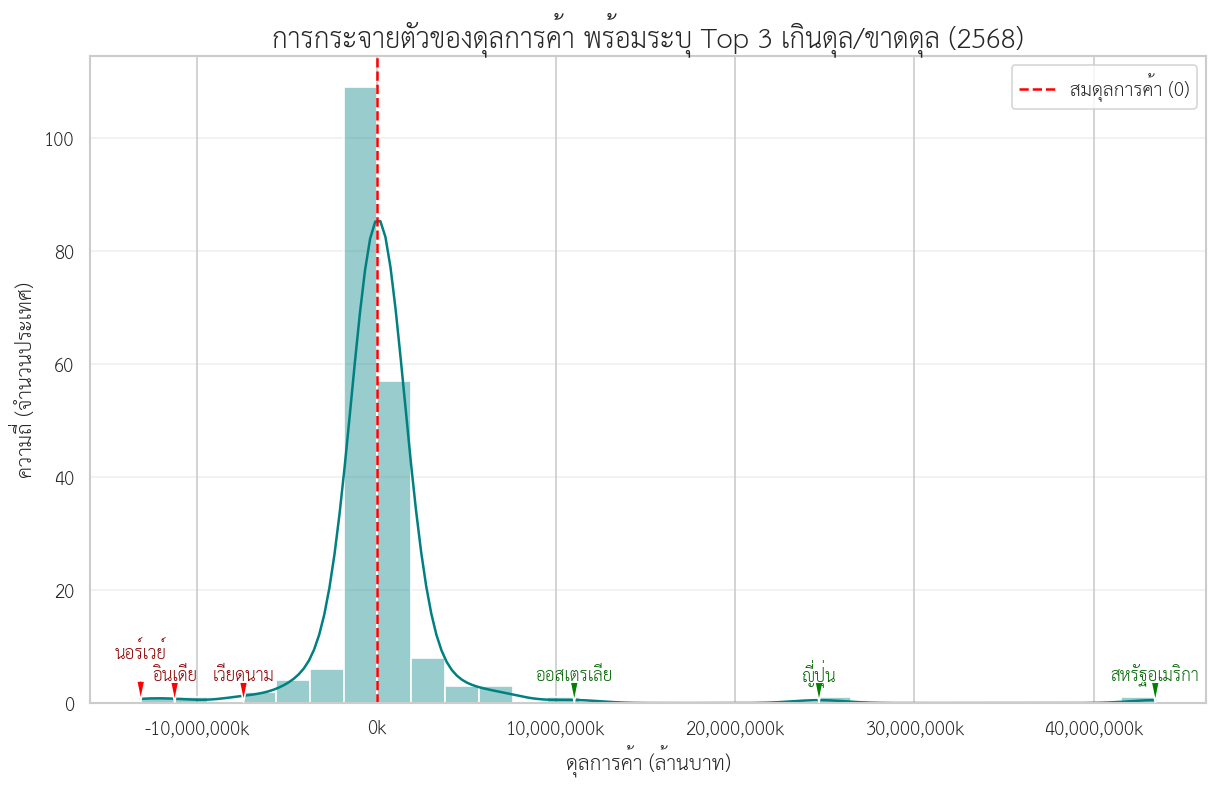


📊 ข้อมูลสรุป:
- จำนวนประเทศที่มีการค้า: 197 ประเทศ
- Mean: 358,753,643.74 ล้านบาท
- Median: 14,463,344.00 ล้านบาท


In [ ]:
# กรองข้อมูลประเทศที่มีการค้าจริง
bal_df = trade_summary.query('Trade_Balance != 0').copy()

plt.figure(figsize=(12, 7))
sns.histplot(bal_df['Trade_Balance'], kde=True, color='teal', bins=30, alpha=0.4)
plt.axvline(0, color='red', linestyle='--', label='สมดุลการค้า (0)')

# รวมกลุ่ม Top 3 เกินดุลและขาดดุล เพื่อใช้ลูปเดียวในการ annotate
points = pd.concat([bal_df.nlargest(3, 'Trade_Balance'), bal_df.nsmallest(3, 'Trade_Balance')])
# Top 1 ขาดดุล
min_val = bal_df['Trade_Balance'].min()

for _, row in points.iterrows():
    color = 'darkgreen' if row['Trade_Balance'] > 0 else 'darkred'
    # ปรับความสูง (offset) พิเศษสำหรับ Top 1 ขาดดุลเพื่อไม่ให้อักษรทับกัน
    y_offset = 8 if row['Trade_Balance'] == min_val else 4

    plt.annotate(row['countryNameTH'],
                 xy=(row['Trade_Balance'], 0),
                 xytext=(row['Trade_Balance'], y_offset),
                 arrowprops=dict(facecolor=color[4:], shrink=0.05, width=1, headwidth=5),
                 ha='center',
                 fontsize=10,
                 fontweight='bold',
                 color=color)

plt.title('การกระจายตัวของดุลการค้า พร้อมระบุ Top 3 เกินดุล/ขาดดุล (2568)', fontsize=16, fontweight='bold')
plt.xlabel('ดุลการค้า (ล้านบาท)', fontsize=12)
plt.ylabel('ความถี่ (จำนวนประเทศ)', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:,.0f}k'))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(
    f"\n📊 ข้อมูลสรุป:\n- จำนวนประเทศที่มีการค้า: {len(bal_df):,} ประเทศ\n"
    f"- Mean: {bal_df['Trade_Balance'].mean():,.2f} ล้านบาท\n"
    f"- Median: {bal_df['Trade_Balance'].median():,.2f} ล้านบาท"
)

In [ ]:
# Bar chart for Top 5 Countries with Trade Surplus
# ประเทศที่ไทยเกินดุลการค้าด้านสินค้าประมงอย่างชัดเจน (Top 5)
fig_surplus = px.bar(
    trade_summary.nlargest(5, 'Trade_Balance'),
    x='Trade_Balance',
    y='countryNameTH',
    orientation='h',
    title='<b>Top 5 Countries with Trade Surplus (Thailand exports more)</b>',
    labels={'Trade_Balance': 'Trade Balance (Baht x 1,000,000)', 'countryNameTH': 'Country'},
    color='Trade_Balance',
    color_continuous_scale=['#008000', '#0000FF'],
    height=500,
    text='Trade_Balance'
)
# แสดงมูลค่าอย่างย่อบนหัว bar
fig_surplus.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig_surplus.update_layout(yaxis={'categoryorder':'total ascending', 'tickfont': {'weight': 'bold'}}, title_x=0.5)
fig_surplus.show()
# ----------
# Bar chart for Top 5 Countries with Trade Deficit
# ประเทศที่ไทยขาดดุลการค้าด้านสินค้าประมงอย่างชัดเจน (Top 5)
fig_deficit = px.bar(
    trade_summary.nsmallest(5, 'Trade_Balance'),
    x='Trade_Balance',
    y='countryNameTH',
    orientation='h',
    title='<b>Top 5 Countries with Trade Deficit (Thailand imports more)</b>',
    labels={'Trade_Balance': 'Trade Balance (Baht x 1,000,000)', 'countryNameTH': 'Country'},
    color='Trade_Balance',
    color_continuous_scale='Reds_r',
    height=500,
    text='Trade_Balance'
)
# แสดงมูลค่าอย่างย่อบนหัว bar
fig_deficit.update_traces(texttemplate='%{text:.2s}', textposition='outside')
fig_deficit.update_layout(yaxis={'categoryorder':'total ascending', 'tickfont': {'weight': 'bold'}}, title_x=0.5)
fig_deficit.show()

In [ ]:
import geopandas as gpd

# แหล่งข้อมูล: Natural Earth 1:50m
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_50m_admin_0_countries.geojson"

try:
    world = gpd.read_file(url, keep_default_na=False)
    print("✅ Loaded Higher Quality World Map (50m resolution) successfully.")

    # ตรวจสอบชื่อคอลัมน์จริงในไฟล์นี้
    print(f"Actual Columns: {world.columns.tolist()[:15]}... (Total {len(world.columns)} cols)")

    # แสดงตัวอย่างข้อมูลเพื่อดูรูปแบบรหัสประเทศ
    # โดยปกติไฟล์จากแหล่งนี้จะใช้ตัวพิมพ์ใหญ่ เช่น 'NAME', 'ISO_A2', 'ISO_A3', 'POSTAL'
    display(world.head(3))
except Exception as e:
    print(f"Error: {e}")

✅ Loaded Higher Quality World Map (50m resolution) successfully.
Actual Columns: ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF']... (Total 169 cols)


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,ADM0_A3,GEOU_DIF,GEOUNIT,GU_A3,SU_DIF,SUBUNIT,SU_A3,BRK_DIFF,NAME,NAME_LONG,BRK_A3,BRK_NAME,BRK_GROUP,ABBREV,POSTAL,FORMAL_EN,FORMAL_FR,NAME_CIAWF,NOTE_ADM0,NOTE_BRK,NAME_SORT,NAME_ALT,MAPCOLOR7,MAPCOLOR8,MAPCOLOR9,MAPCOLOR13,POP_EST,POP_RANK,POP_YEAR,GDP_MD,GDP_YEAR,ECONOMY,INCOME_GRP,FIPS_10,ISO_A2,ISO_A2_EH,ISO_A3,ISO_A3_EH,ISO_N3,ISO_N3_EH,UN_A3,WB_A2,WB_A3,WOE_ID,WOE_ID_EH,WOE_NOTE,ADM0_ISO,ADM0_DIFF,ADM0_TLC,ADM0_A3_US,ADM0_A3_FR,ADM0_A3_RU,ADM0_A3_ES,ADM0_A3_CN,ADM0_A3_TW,ADM0_A3_IN,ADM0_A3_NP,ADM0_A3_PK,ADM0_A3_DE,ADM0_A3_GB,ADM0_A3_BR,ADM0_A3_IL,ADM0_A3_PS,ADM0_A3_SA,ADM0_A3_EG,ADM0_A3_MA,ADM0_A3_PT,ADM0_A3_AR,ADM0_A3_JP,ADM0_A3_KO,ADM0_A3_VN,ADM0_A3_TR,ADM0_A3_ID,ADM0_A3_PL,ADM0_A3_GR,ADM0_A3_IT,ADM0_A3_NL,ADM0_A3_SE,ADM0_A3_BD,ADM0_A3_UA,ADM0_A3_UN,ADM0_A3_WB,CONTINENT,REGION_UN,SUBREGION,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,MIN_ZOOM,MIN_LABEL,MAX_LABEL,LABEL_X,LABEL_Y,NE_ID,WIKIDATAID,NAME_AR,NAME_BN,NAME_DE,NAME_EN,NAME_ES,NAME_FA,NAME_FR,NAME_EL,NAME_HE,NAME_HI,NAME_HU,NAME_ID,NAME_IT,NAME_JA,NAME_KO,NAME_NL,NAME_PL,NAME_PT,NAME_RU,NAME_SV,NAME_TR,NAME_UK,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,TLC_DIFF,FCLASS_TLC,FCLASS_US,FCLASS_FR,FCLASS_RU,FCLASS_ES,FCLASS_CN,FCLASS_TW,FCLASS_IN,FCLASS_NP,FCLASS_PK,FCLASS_DE,FCLASS_GB,FCLASS_BR,FCLASS_IL,FCLASS_PS,FCLASS_SA,FCLASS_EG,FCLASS_MA,FCLASS_PT,FCLASS_AR,FCLASS_JP,FCLASS_KO,FCLASS_VN,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,3,Zimbabwe,ZWE,0,2,Sovereign country,1,Zimbabwe,ZWE,0,Zimbabwe,ZWE,0,Zimbabwe,ZWE,0,Zimbabwe,Zimbabwe,ZWE,Zimbabwe,None,Zimb.,ZW,Republic of Zimbabwe,None,Zimbabwe,None,None,Zimbabwe,None,1,5,3,9,14645468.0,14,2019,21440,2019,5. Emerging region: G20,5. Low income,ZI,ZW,ZW,ZWE,ZWE,716,716,716,ZW,ZWE,23425004,23425004,Exact WOE match as country,ZWE,None,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,ZWE,-99,-99,Africa,Africa,Eastern Africa,Sub-Saharan Africa,8,8,5,-99,1,0.0,2.5,8.0,29.925444,-18.911640,1159321441,Q954,زيمبابوي,জিম্বাবুয়ে,Simbabwe,Zimbabwe,Zimbabue,زیمبابوه,Zimbabwe,Ζιμπάμπουε,זימבבואה,ज़िम्बाब्वे,Zimbabwe,Zimbabwe,Zimbabwe,ジンバブエ,짐바브웨,Zimbabwe,Zimbabwe,Zimbábue,Зимбабве,Zimbabwe,Zimbabve,Зімбабве,زمبابوے,Zimbabwe,津巴布韦,辛巴威,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"POLYGON ((31.28789 -22.40205, 31.19727 -22.344..."
1,Admin-0 country,1,3,Zambia,ZMB,0,2,Sovereign country,1,Zambia,ZMB,0,Zambia,ZMB,0,Zambia,ZMB,0,Zambia,Zambia,ZMB,Zambia,None,Zambia,ZM,Republic of Zambia,None,Zambia,None,None,Zambia,None,5,8,5,13,17861030.0,14,2019,23309,2019,7. Least developed region,4. Lower middle income,ZA,ZM,ZM,ZMB,ZMB,894,894,894,ZM,ZMB,23425003,23425003,Exact WOE match as country,ZMB,None,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,ZMB,-99,-99,Africa,Africa,Eastern Africa,Sub-Saharan Africa,6,6,6,-99,1,0.0,3.0,8.0,26.395298,-14.660804,1159321439,Q953,زامبيا,জাম্বিয়া,Sambia,Zambia,Zambia,زامبیا,Zambie,Ζάμπια,זמביה,ज़ाम्बिया,Zambia,Zambia,Zambia,ザンビア,잠비아,Zambia,Zambia,Zâmbia,Замбия,Zambia,Zambiya,Замбія,زیمبیا,Zambia,赞比亚,尚比亞,Admin-0 country,None,Admin-0 country,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"POLYGON ((30.39609 -15.64307, 30.25068 -15.643..."
2,Admin-0 country,1,3,Yemen,YEM,0,2,Sovereign country,1,Yemen,YEM,0,Yemen,YEM,0,Yemen,YEM,0,Yemen,Yemen,YEM,Yemen,None,Yem.,YE,Republic of Yemen,None,Yemen,None,None,"Yemen, Rep.",None,5,3,3,11,29161922.0,15,2019,22581,2019,7. Least developed region,4. Lower middle income,YM,YE,YE,YEM,YEM,887,887,887,RY,YEM,23425

In [ ]:
# 1. แก้ไขรหัส ISO ที่ขาดหายไป (มักใส่ -99) ในแผนที่ Natural Earth ความละเอียดสูง (50m) สำหรับประเทศคู่ค้าหลัก
# สำหรับ Norway และ France พื้นที่อาจนั้นถูกมองว่าเป็น 'Sovereign' ที่มีส่วนประกอบหลายพื้นที่ (เช่น แผ่นดินใหญ่ vs เกาะต่างๆ)
# ทำให้รหัสที่ระดับ Admin-0 ไม่ถูกระบุไว้อย่างชัดเจน
world.loc[world['NAME'] == 'Norway', 'ISO_A2'] = 'NO'
world.loc[world['NAME'] == 'Norway', 'ISO_A3'] = 'NOR'
world.loc[world['NAME'] == 'France', 'ISO_A2'] = 'FR'
world.loc[world['NAME'] == 'France', 'ISO_A3'] = 'FRA'
# Taiwan รหัสเป็น '-99' หรือ 'TW' (บางครั้งเป็น CN-TW) เนื่องจากสถานะทางการเมืองระหว่างประเทศ ทำให้บางแหล่งไม่ระบุรหัส ISO
world.loc[world['NAME'] == 'Taiwan', 'ISO_A2'] = 'TW'
world.loc[world['NAME'] == 'Taiwan', 'ISO_A3'] = 'TWN'
# India มักมีปัญหาในเวอร์ชัน Low resolution ที่รหัสอาจตกหล่นระหว่างการทำ Geometry Simplify
world.loc[world['NAME'] == 'India', 'ISO_A2'] = 'IN'
world.loc[world['NAME'] == 'India', 'ISO_A3'] = 'IND'

# 2. เตรียมข้อมูล Merge
plotly_trade = trade_summary.merge(world[['ISO_A2', 'ISO_A3', 'NAME']], left_on='countryID', right_on='ISO_A2', how='left')

# 3. คำนวณจุดกึ่งกลาง (Normalized Zero)
vmin, vmax = trade_summary['Trade_Balance'].min(), trade_summary['Trade_Balance'].max()
zero_pos = (0 - vmin) / (vmax - vmin)

# 4. สร้าง Custom Color Scale
custom_plotly_scale = [
    [0.0, "#800000"], [zero_pos * 0.5, "#ff0000"], [zero_pos, "#d3d3d3"],
    [zero_pos + (1 - zero_pos) * 0.5, "#008000"], [1.0, "#0000ff"]
]

# 5. สร้าง Choropleth Map
fig = px.choropleth(
    plotly_trade,
    locations="ISO_A3",
    color="Trade_Balance",
    hover_name="countryNameTH",
    color_continuous_scale=custom_plotly_scale,
    range_color=[vmin, vmax],
    labels={'Trade_Balance': 'ดุลการค้า (ล้านบาท)'},
    title='<b>Interactive Trade Balance Map (High Res + ISO Fix)</b>'
)

fig.update_layout(
    title_x=0.5,
    geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular',
             showland=True, landcolor='black', showocean=True, oceancolor='white', bgcolor='black'),
    margin=dict(l=0, r=0, b=0, t=50)
)
fig.show()

#### No Trade Country List

In [ ]:
# ตรวจสอบรายชื่อประเทศที่เหลือ
trading_ids = set(trade_summary['countryID'].unique())
all_map_ids = set(world['ISO_A2'].unique())
missing_ids = all_map_ids - trading_ids
no_trade_list = world[world['ISO_A2'].isin(missing_ids)][['ISO_A2', 'ISO_A3', 'NAME']].drop_duplicates().sort_values('NAME')
print(f"\n⬛ รายชื่อประเทศที่ไม่มีข้อมูลการค้า(สีดำบนแผนที่) จำนวน {len(no_trade_list)} ประเทศ:")
display(no_trade_list)


⬛ รายชื่อประเทศที่ไม่มีข้อมูลการค้า(สีดำบนแผนที่) จำนวน 52 ประเทศ:


,ISO_A2,ISO_A3,NAME
237,AF,AFG,Afghanistan
234,AD,AND,Andorra
21,AI,AIA,Anguilla
239,AQ,ATA,Antarctica
229,-99,-99,Ashmore and Cartier Is.
18,IO,IOT,Br. Indian Ocean Ter.
25,VG,VGB,British Virgin Is.
206,BI,BDI,Burundi
201,CV,CPV,Cabo Verde
200,CF,CAF,Central African Rep.


#### **สรุปภาพรวมตลาดสินค้าประมงไทย ในปี พ.ศ. 2568:**

**1. ภาพรวมมูลค่า**

💰 ประเทศไทยมีมูลค่าการค้าสินค้าประมงรวมทั้งสิ้น **375,567 ล้านล้านบาท** (3.7 แสนล้านล้านบาท) โดยแบ่งเป็น:
- 📥 **มูลค่าการนำเข้า:** 152,446 ล้านล้านบาท (1.5 แสนล้านล้านบาท คิดเป็น 40.59% ของมูลค่ารวม)
- 📤 **มูลค่าการส่งออก:** 223,121 ล้านล้านบาท (2.2 แสนล้านล้านบาท คิดเป็น 59.41% ของมูลค่ารวม)
- ⚖️ **ดุลการค้า:** ไทยเกินดุลการค้ากับประเทศส่วนใหญ่ (Median เป็นบวก) 70,674 ล้านล้านบาท โดยเฉพาะกลุ่มประเทศที่มีกำลังซื้อสูง และมีท่าเรือขนาดใหญ่

**2. วิเคราะห์การค้า**

🫱🏻🫲🏻 **คู่ค้าหลัก**:

- 📥 ตลาดนำเข้าสินค้าประมงที่สำคัญที่สุดคือ **จีน** และ**นอร์เวย์**

- 📤 ตลาดส่งออกสินค้าประมงที่สำคัญที่สุดคือ **สหรัฐอเมริกา** และ**ญี่ปุ่น**

🗺️ **ภูมิศาสตร์**: แผนที่โลกแสดงให้เห็นชัดเจนว่ามีปริมาณการค้าอยู่ในประเทศที่มีทางออกสู่ทะเล (Coastal States) ยืนยันว่าการขนส่งทางเรือเป็นหัวใจสำคัญของอุตสาหกรรมนี้

⬛ **ประเทศที่ไม่มีข้อมูลการซื้อขายสินค้าประมงกับไทย**: จากรายชื่อ 52 ประเทศใน no_trade_list สะท้อนถึงอุปสรรคด้าน ลอจิสติกส์ กำลังซื้อ และความมั่นคง เป็นหลัก

1. กลุ่มประเทศ Landlocked (ไร้ทางออกสู่ทะเล): หลายประเทศในลิสต์ เช่น Afghanistan, Chad, Burundi, Rwanda, Tajikistan, และ Kyrgyzstan เป็นประเทศที่ไม่มีชายฝั่งทะเล ทำให้การขนส่งสินค้าสดหรือแช่แข็งทำได้ยากและมีต้นทุนสูงมาก

2. กลุ่มรัฐขนาดเล็กและเกาะห่างไกล: มีประเทศเกาะขนาดเล็กจำนวนมาก เช่น Anguilla, Montserrat, Niue, Pitcairn Is., และ Saint Helena ซึ่งมีประชากรน้อยและตั้งอยู่โดดเดี่ยว ทำให้มูลค่าการค้าอาจไม่คุ้มทุนในการจัดส่ง

3. ปัจจัยด้านความขัดแย้ง และภูมิรัฐศาสตร์: ประเทศที่มีสถานะไม่มั่นคงหรือถูกคว่ำบาตรทางเศรษฐกิจ เช่น North Korea (เกาหลีเหนือ) หรือพื้นที่ที่มีความขัดแย้งยืดเยื้ออย่าง Western Sahara และ Central African Rep. มักจะมีข้อจำกัดในการทำธุรกรรมระหว่างประเทศ

4. ข้อจำกัดด้านมาตรฐานข้อมูล (Data Quality): สังเกตว่ายังมีรหัส -99 (เช่น Kosovo, Somaliland) ซึ่งเป็นพื้นที่ที่มีสถานะทางการเมืองทับซ้อน ทำให้ฐานข้อมูลศุลกากรอาจไม่ได้จัดกลุ่มแยกออกมาเป็นประเทศคู่ค้าอย่างชัดเจน

5. กลุ่มประเทศที่มีกำลังซื้อต่ำ: ส่วนใหญ่อยู่ในกลุ่ม Least Developed Countries (LDC) ในแอฟริกา ซึ่งเน้นการบริโภคสินค้าเกษตรพื้นฐานภายในท้องถิ่นมากกว่าการนำเข้าสินค้าประมงแปรรูปจากไทยครับ

### 4.2 🦐 สินค้าประมงชนิดใดคือหัวใจของการค้าไทย?

Fisheries Product Structure (โครงสร้างสินค้าประมงของไทย) โดยจัดกลุ่มตาม HS Code
- สินค้าประเภทใดที่ไทย ส่งออกมากกว่านำเข้า (Net Export)
- สินค้าประเภทใดที่ไทย ต้องพึ่งพาการนำเข้า (Net Import)

In [ ]:
# 1. เตรียมข้อมูลสรุปตาม HS Code (heading11)
product_trade_raw = cleaned_df.groupby(
    ['heading11', 'productDetailTH', 'tradeflow']
)['price'].sum().unstack(fill_value=0) # ลำดับคอลัมน์ที่ unstack ออกมาจะเป็น [1, 2]

product_trade = product_trade_raw.reset_index()
# Rename columns 1=Import, 2=Export
product_trade.columns = ['HS_Code', 'Product_Name', 'Import_Value', 'Export_Value']

# คำนวณ Net Trade และ Trade Balance
product_trade['Trade_Balance'] = product_trade['Export_Value'] - product_trade['Import_Value']

# 2. แยกกลุ่ม Net Export และ Net Import
net_export = product_trade[product_trade['Trade_Balance'] > 0].nlargest(5, 'Trade_Balance')
net_import = product_trade[product_trade['Trade_Balance'] < 0].nsmallest(5, 'Trade_Balance').copy()

# 3. Visualization: Top 5 Net Export Products
fig_net_exp = px.bar(
    net_export,
    x='Trade_Balance',
    y='Product_Name',
    orientation='h',
    title='<b>Top 5 สินค้าที่ไทยส่งออกมากกว่านำเข้า (Net Export)</b>',
    labels={'Trade_Balance': 'ดุลการค้าบวก (ล้านบาท)', 'Product_Name': 'ประเภทสินค้า'},
    color='Trade_Balance',
    color_continuous_scale='Greens',
    height=500
)
fig_net_exp.update_layout(yaxis={'categoryorder':'total ascending', 'tickfont': {'size': 12}}, title_x=0.5)
fig_net_exp.show()

# 4. Visualization: Top 5 Net Import Products
fig_net_imp = px.bar(
    net_import,
    x='Trade_Balance',
    y='Product_Name',
    orientation='h',
    title='<b>Top 5 สินค้าที่ไทยพึ่งพาการนำเข้า (Net Import)</b>',
    labels={'Trade_Balance': 'ดุลการค้าลบ (ล้านบาท)', 'Product_Name': 'ประเภทสินค้า'},
    color='Trade_Balance',
    color_continuous_scale='Reds_r',
    height=500
)
fig_net_imp.update_layout(yaxis={'categoryorder':'total ascending', 'tickfont': {'size': 12}}, title_x=0.5)
fig_net_imp.show()

จากกราฟแท่งจัดอันดับ จะเห็นภาพคร่าว ๆ ว่า

1. กลุ่มสินค้าที่ไทยได้เปรียบ (Net Export): โดดเด่นที่สุดคือ 'ปลาทูน่าแปรรูป' และ 'อาหารสัตว์เลี้ยงที่มีปลา' ซึ่งแสดงถึงศักยภาพระดับโลกของไทยในฐานะ Hub การแปรรูปอาหารสัตว์น้ำ
2. กลุ่มสินค้าที่ไทยพึ่งพาการนำเข้า (Net Import): ส่วนใหญ่เป็นวัตถุดิบต้นน้ำอย่าง 'ปลาแช่แข็ง' (เช่น ทูน่าแช่แข็ง, ปลาหมึก) และปลาพรีเมียม (แซลมอน) เพื่อนำมาเป็นวัตถุดิบป้อนโรงงานแปรรูป หรือบริโภคสด

#### Categorize Fisheries Products

แผนภาพ Treemap เหมาะสำหรับการแสดงข้อมูลเชิงลำดับชั้นและความสัมพันธ์แบบส่วนต่อภาพรวมในคราวเดียวกัน

In [ ]:
# เตรียมข้อมูลจัดกลุ่มตามคีย์เวิร์ด
def categorize_product(name):
    name = str(name)
    cat = 'อื่นๆ'
    if ('มีชีวิต' in name or 'สำหรับทำพันธุ์' in name) and 'ไม่มีชีวิต' not in name: cat = 'มีชีวิต'
    elif 'หมึก' in name: cat = 'กลุ่มหมึก'
    elif 'ปลา' in name and 'น้ำปลา' not in name: cat = 'กลุ่มปลา'
    elif 'น้ำปลา' in name or 'รส' in name or 'ใช้แทน' in name: cat = 'กลุ่มเครื่องปรุง'
    elif ('ไข่' in name or 'คาร์เวีย' in name) and 'ไม่' not in name: cat = 'กลุ่มไข่'
    elif 'หอย' in name: cat = 'กลุ่มหอย'
    elif 'กุ้ง' in name or 'ลอบสเตอร์' in name or 'ล็อบเสตอร์' in name: cat = 'กลุ่มกุ้ง'
    elif 'ปู' in name: cat = 'กลุ่มปู'

    if 'แช่เย็นจนแข็ง' in name or 'แช่แข็ง' in name: type_str = ' (แช่แข็ง)'
    else: type_str = ''
    return cat + type_str

# เตรียม DataFrame พื้นฐาน
df_category = cleaned_df.copy()
df_category['Category'] = df_category['productDetailTH'].apply(categorize_product)
df_category['Trade_Type'] = df_category['tradeflow'].map({1: 'นำเข้า (Import)', 2: 'ส่งออก (Export)'})

treemap_data = df_category.groupby(['Trade_Type', 'Category', 'productDetailTH'])['price'].sum().reset_index()

# สร้าง Interactive Treemap
fig_tree = px.treemap(
    treemap_data[treemap_data['price'] > 0],
    path=[px.Constant('การค้าประมงไทย'), 'Trade_Type', 'Category', 'productDetailTH'],
    values='price',
    color='Trade_Type',
    color_discrete_map={'(?)':'white', 'นำเข้า (Import)':'#EF553B', 'ส่งออก (Export)':'#636EFA'},
    title='<b>Market Share Explorer: Click to Drill-down into Sub-categories</b>',
    height=750
)

fig_tree.update_traces(textinfo='label+percent parent')
fig_tree.update_layout(title_x=0.5)
fig_tree.show()

In [ ]:
# คำนวณ Net Trade (Export - Import) รายกลุ่มสินค้า
net_trade_data = df_category.groupby(['Category', 'tradeflow'])['price'].sum().unstack(fill_value=0)
# 1=Import, 2=Export
net_trade_data['Net_Value'] = net_trade_data[2] - net_trade_data[1]
net_trade_data = net_trade_data.reset_index().sort_values('Net_Value', ascending=True)

# สร้าง Diverging Bar Chart สำหรับ Net Export/Import
fig_net = px.bar(
    net_trade_data,
    x='Net_Value',
    y='Category',
    orientation='h',
    title='<b>Net Trade by Product Category (Net Export vs Net Import)</b>',
    labels={'Net_Value': 'ดุลการค้าสุทธิ (ล้านบาท)', 'Category': 'กลุ่มสินค้า'},
    color='Net_Value',
    # ใช้สเกลสี แดง (นำเข้าสุทธิ) - เทา (สมดุล) - เขียว (ส่งออกสุทธิ)
    color_continuous_scale='RdYlGn',
    height=600
)

# เพิ่มเส้นแนวตั้งที่ 0 เพื่อให้เห็นจุดสมดุลชัดเจน
fig_net.add_vline(x=0, line_dash="dash", line_color="black")

fig_net.update_layout(title_x=0.5, yaxis={'tickfont': {'weight': 'bold'}})
fig_net.show()

#### Market Share Analysis

In [ ]:
# 1. Data Preparation: Define target countries for Top 3 Surplus and Deficit partners
top3_surplus = ['US', 'JP', 'AU']
top3_deficit = ['NO', 'IN', 'VN']
target_countries = top3_surplus + top3_deficit

flows = []
# Loop through trade directions: (1=Import: Country -> Category) and (2=Export: Category -> Country)
for trade_type, src_col, tgt_col in [(1, 'countryNameTH', 'Category'), (2, 'Category', 'countryNameTH')]:
    flow = df_category.query('countryID in @target_countries and tradeflow == @trade_type') \
           .groupby([src_col, tgt_col])['price'].sum().reset_index()
    flow.columns = ['source', 'target', 'value']
    flows.append(flow)

# Combine import and export flows into a single DataFrame for Sankey
sankey_data = pd.concat(flows)

# 2. Nodes Preparation: Calculate net trade balance per category to determine node colors
cat_balance = df_category.groupby(['Category', 'tradeflow'])['price'].sum().unstack(fill_value=0)
cat_balance['balance'] = cat_balance.get(2, 0) - cat_balance.get(1, 0)

# Identify unique nodes and map them to indices
all_nodes = list(pd.concat([sankey_data['source'], sankey_data['target']]).unique())
node_map = {name: i for i, name in enumerate(all_nodes)}

# Assign colors to nodes: Green for surplus partners/categories, Red for deficit ones
node_colors = []
for name in all_nodes:
    if name in ['สหรัฐอเมริกา', 'ญี่ปุ่น', 'ออสเตรเลีย']: color = "#27ae60"
    elif name in ['นอร์เวย์', 'อินเดีย', 'เวียดนาม']: color = "#e74c3c"
    elif name in cat_balance.index: color = "#27ae60" if cat_balance.loc[name, 'balance'] > 0 else "#e74c3c"
    else: color = "#34495e"
    node_colors.append(color)

# 3. Links Preparation: Set link colors using a standard Pastel palette
link_colors_palette = px.colors.qualitative.Pastel1

links = {'source': [], 'target': [], 'value': [], 'color': []}
for i, (_, row) in enumerate(sankey_data.iterrows()):
    links['source'].append(node_map[row['source']])
    links['target'].append(node_map[row['target']])
    links['value'].append(row['value'])
    # Cycle through the pastel palette for each flow link
    links['color'].append(link_colors_palette[i % len(link_colors_palette)])

# 4. Visualization: Generate the Sankey Diagram
fig_flow = go.Figure(data=[go.Sankey(
    node = dict(pad=15, thickness=20, line=dict(color="black", width=0.5), label=all_nodes, color=node_colors),
    link = dict(source=links['source'], target=links['target'], value=links['value'], color=links['color'])
)])

fig_flow.update_layout(
    title_text="<b>Fishery Supply Chain Flow (green = surplus | red = deficit)</b>",
    font_size=12, title_x=0.5, height=700
)
fig_flow.show()

In [ ]:
# สรุปสินค้าเด่นแบบแยกประเภทนำเข้า/ส่งออก (Unique Products & Summed Values)
print('🔍 เจาะลึกตัวอย่างสินค้าหลักรายประเทศ (Top 3 Surplus/Deficit):')

for group_name, countries in [('กลุ่มเกินดุล (Surplus)', top3_surplus), ('กลุ่มขาดดุล (Deficit)', top3_deficit)]:
    print(f'\n' + '='*30 + f' {group_name} ' + '='*30)

    for cid in countries:
        subset = df_category[df_category['countryID'] == cid]
        country_name = subset['countryNameTH'].unique()[0]
        print(f'\n🌍 ประเทศ: {country_name}')

        # 1. สินค้าที่ประเทศนี้ส่งมาให้ไทย (นำเข้า - Tradeflow 1)
        print(f'   📥 สินค้าหลักที่ไทย [นำเข้า] จาก {country_name}:')
        imports = subset[subset['tradeflow'] == 1].groupby('productDetailTH')['price'].sum().nlargest(3)
        if not imports.empty:
            for item, val in imports.items():
                print(f'      ➜ {item} ({val:,.0f} ล้านบาท)')
        else:
            print('      (ไม่มีข้อมูลการนำเข้า)')

        # 2. สินค้าที่ไทยส่งไปให้ประเทศนี้ (ส่งออก - Tradeflow 2)
        print(f'   📤 สินค้าหลักที่ไทย [ส่งออก] ไป {country_name}:')
        exports = subset[subset['tradeflow'] == 2].groupby('productDetailTH')['price'].sum().nlargest(3)
        if not exports.empty:
            for item, val in exports.items():
                print(f'      ➜ {item} ({val:,.0f} ล้านบาท)')
        else:
            print('      (ไม่มีข้อมูลการส่งออก)')

🔍 เจาะลึกตัวอย่างสินค้าหลักรายประเทศ (Top 3 Surplus/Deficit):

============================== กลุ่มเกินดุล (Surplus) ==============================

🌍 ประเทศ: สหรัฐอเมริกา
   📥 สินค้าหลักที่ไทย [นำเข้า] จาก สหรัฐอเมริกา:
      ➜ ปลาแซลมอนแปซิฟิกอื่นๆ แช่เย็นจนแข็ง (2,424,452,351 ล้านบาท)
      ➜ เนื้อปลาอลาสกาพอลลัค แบบฟิเล  แช่เย็นจนแข็ง (533,485,281 ล้านบาท)
      ➜ เนื้อปลาอลาสกาพอลลัค แบบอื่นๆ  แช่เย็นจนแข็ง (530,541,551 ล้านบาท)
   📤 สินค้าหลักที่ไทย [ส่งออก] ไป สหรัฐอเมริกา:
      ➜ อาหารสุนัขหรือแมวที่มีปลาบรรจุภาชนะที่อากาศเข้าออกไม่ได้ (10,513,506,961 ล้านบาท)
      ➜ ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้ (10,470,427,260 ล้านบาท)
      ➜ ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโต ที่บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้ (5,367,064,458 ล้านบาท)

🌍 ประเทศ: ญี่ปุ่น
   📥 สินค้าหลักที่ไทย [นำเข้า] จาก ญี่ปุ่น:
      ➜ ปลาซาร์ดีน แช่เย็นจนแข็ง (1,809,103,326 ล้านบาท)
      ➜ หอยเชลล์ และหอยควีนสแกลลอปของตระกูลเพกเตน คลามิส หรือพลาโคเพกเตน แช่เย็นจนแข็ง

วิเคราะห์ความแตกต่างของคู่ค้าหลัก:

1. กลุ่มเกินดุล (Surplus) สีเขียว - สหรัฐอเมริกา ญี่ปุ่น และออสเตรเลีย:

- **โครงสร้าง**: ทั้งสามประเทศนำเข้า 'กลุ่มปลา' และ 'กลุ่มกุ้ง' จากไทยเป็นหลัก ในปริมาณมหาศาล
- **จุดเด่น**: เน้นการส่งออกผลิตภัณฑ์สำเร็จรูปที่มีมูลค่าเพิ่ม (Value-added) เช่น **อาหารสุนัขหรือแมวที่มีปลา** และ **ปลาทูน่าบรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้** ซึ่งสร้างรายได้มหาศาลให้กับไทย

2. กลุ่มขาดดุล (Deficit) - นอร์เวย์ อินเดีย และเวียดนาม:

- **นอร์เวย์**: ข้อมูลยืนยันชัดเจนว่าไทยนำเข้า **ปลาแซลมอนแอตแลนติก สด แช่เย็น** และ **ปลาเทราต์** มูลค่าสูงมาก ซึ่งเป็นวัตถุดิบระดับพรีเมียมที่เราไม่ได้ผลิตเอง
- **อินเดีย**: ไทยนำเข้าทั้ง **ปลาหมึกกล้วยแช่เย็นจนแข็ง** และ **ปลาอินเดียนแมคเคอเรล** เพื่อนำมาเป็นวัตถุดิบป้อนโรงงานแปรรูปในประเทศ
- **เวียดนาม**: เน้นการนำเข้า **ซูริมิ (เนื้อปลาบด)** และ **ปลาหมึกกล้วยแห้ง** เพื่อนำมาสร้างมูลค่าเพิ่มในไทยเช่นกัน

แผนภาพ Sankey ช่วยให้เห็นภาพ 'ห่วงโซ่อุปทาน' (Supply Chain) ว่าไทยทำหน้าที่เป็นจุดรับวัตถุดิบจากกลุ่มประเทศหนึ่ง (เช่น นอร์เวย์, อินเดีย, เวียดนาม) เพื่อนำมาสร้างมูลค่าเพิ่มและส่งออกไปยังอีกกลุ่มหนึ่ง (เช่น สหรัฐฯ, ญี่ปุ่น, ออสเตรเลีย) ยืนยันสถานะการเป็น Global Processing Hub ของไทย

#### 💎 High-Value (Premium) Products

In [ ]:
# 1. เตรียมข้อมูลดุลการค้าและมูลค่าต่อหน่วยแยกตาม Category
cat_trade = df_category.groupby(['Category', 'tradeflow'])[['weight', 'price']].sum().unstack(fill_value=0)

# คำนวณผลสรุป
summary_cat = pd.DataFrame({
    'Weight_Sum': cat_trade['weight'].sum(axis=1),
    'Price_Sum': cat_trade['price'].sum(axis=1),
    'Export_Val': cat_trade[('price', 2)],
    'Import_Val': cat_trade[('price', 1)],
})

summary_cat['Trade_Balance'] = summary_cat['Export_Val'] - summary_cat['Import_Val']
summary_cat['Unit_Value'] = summary_cat['Price_Sum'] / summary_cat['Weight_Sum']
summary_cat = summary_cat.reset_index()

# 2. Visualization: Strategy Map (Trade Balance vs Unit Value)
fig = px.scatter(
    summary_cat,
    x='Trade_Balance',
    y='Unit_Value',
    size='Price_Sum',
    color='Category',
    text='Category',
    hover_name='Category',
    title='<b>Strategy Map: Trade Balance vs Unit Value by Category</b>',
    labels={'Trade_Balance': 'ดุลการค้า (ล้านบาท)', 'Unit_Value': 'มูลค่าต่อหน่วย (ล้านบาท/1,000 กก.)'},
    height=600,
    size_max=45
)

fig.add_vline(
    x=0,
    line_dash="dash",
    line_color="red",
    annotation_text="Trade Equilibrium",
    annotation_position="top"
)

fig.update_traces(textposition='top center')
fig.update_layout(title_x=0.5, yaxis_type='log')
fig.show()

print('\n📊 สรุปมูลค่ารายกลุ่มสินค้า:')
display(summary_cat[['Category', 'Trade_Balance', 'Unit_Value', 'Price_Sum']].sort_values('Unit_Value', ascending=False).reset_index(drop=True))


📊 สรุปมูลค่ารายกลุ่มสินค้า:


,Category,Trade_Balance,Unit_Value,Price_Sum
0,กลุ่มกุ้ง (แช่แข็ง),9826092189,303.325509,17917611003
1,กลุ่มไข่,-734973530,272.997427,943730538
2,กลุ่มกุ้ง,26656247909,209.310129,28969113923
3,อื่นๆ (แช่แข็ง),-433053653,179.727566,855146273
4,กลุ่มหอย (แช่แข็ง),-2017495408,159.016036,3404726698
5,กลุ่มปู,-292354999,151.073402,2340989025
6,อื่นๆ,-2646580880,143.732584,4864503556
7,กลุ่มหมึก (แช่แข็ง),-8770782325,143.401421,26690686089
8,กลุ่มหมึก,-2332163932,141.872456,5743649912
9,มีชีวิต,2070326077,109.086472,6439209699


In [ ]:
# 1. Compute unit values for all products
# weight unit: 1,000 kg | price unit: 1,000,000 Baht
product_stats = (df_category.groupby(['Category', 'productDetailTH'])[['weight', 'price']]
                 .sum().reset_index().query('weight > 0'))
product_stats['unit_value'] = product_stats['price'] / product_stats['weight']

# 2. Calculate average unit value per category
cat_means = (product_stats.groupby('Category')['unit_value']
             .mean().reset_index()
             .rename(columns={'unit_value': 'cat_avg'}))

# 3. Join stats with category averages and identify top 2 products per group
analysis_df = pd.merge(product_stats, cat_means, on='Category')
analysis_df['rank'] = analysis_df.groupby('Category')['unit_value'].rank(ascending=False, method='first')

# Filter for top 2 and calculate performance metrics using .query()
top2_products = analysis_df.query('rank <= 2').copy()
top2_products['diff_val'] = top2_products['unit_value'] - top2_products['cat_avg']
top2_products['pct_diff'] = (top2_products['diff_val'] / top2_products['cat_avg']) * 100

# 4. Display results
print('📊 Analysis: High-Value Products vs. Category Average')
# Sort categories by their average value descending
for cat in cat_means.sort_values('cat_avg', ascending=False)['Category']:
    avg_val = cat_means.query('Category == @cat')['cat_avg'].values[0]
    print(f'\n🔹 Group: {cat}')
    print(f'   ➜ Category Avg: {avg_val:,.2f} M.Baht/1,000kg')

    # Use .query() to filter products for the current category with a positive difference
    items = top2_products.query('Category == @cat and diff_val > 0').sort_values('unit_value', ascending=False)

    for _, row in items.iterrows():
        print(f"      🏆 {row['productDetailTH']}")
        print(f"         Unit Value: {row['unit_value']:,.2f} | +{row['diff_val']:,.2f} (+{row['pct_diff']:.1f}%) above avg")

📊 Analysis: High-Value Products vs. Category Average

🔹 Group: กลุ่มไข่
   ➜ Category Avg: 5,014.97 M.Baht/1,000kg
      🏆 คาร์เวีย
         Unit Value: 19,408.82 | +14,393.85 (+287.0%) above avg

🔹 Group: อื่นๆ
   ➜ Category Avg: 4,213.58 M.Baht/1,000kg
      🏆 สัตว์ในตอนที่3 ที่ไม่มีชีวิต
         Unit Value: 110,128.50 | +105,914.92 (+2513.7%) above avg
      🏆 ของสัตว์น้ำที่ไม่มีกระดูกสันหลังอื่น ๆ
         Unit Value: 26,303.17 | +22,089.59 (+524.2%) above avg

🔹 Group: มีชีวิต
   ➜ Category Avg: 2,063.26 M.Baht/1,000kg
      🏆 จระเข้มีชีวิต
         Unit Value: 31,084.71 | +29,021.45 (+1406.6%) above avg
      🏆 กุ้งกุลาดำ (พิเนอัสโมโนดอน) สำหรับทำพันธุ์
         Unit Value: 17,321.04 | +15,257.78 (+739.5%) above avg

🔹 Group: กลุ่มกุ้ง
   ➜ Category Avg: 593.39 M.Baht/1,000kg
      🏆 ร็อกลอบสเตอร์และกุ้งหัวโขนอื่นๆ รมควัน
         Unit Value: 2,570.00 | +1,976.61 (+333.1%) above avg
      🏆 ลอบสเตอร์ (ชนิดโฮมารัส) สดหรือแช่เย็น
         Unit Value: 2,408.20 | +1,814.80 (+305.8%)

1. กลุ่ม High Margin (ขวา-บน): 'กลุ่มกุ้ง' และ 'กลุ่มกุ้ง (แช่แข็ง)'

อยู่ในโซนที่ดีที่สุด คือมีมูลค่าต่อหน่วยสูง (High Margin) และไทยยังเกินดุลการค้า

2. กลุ่มปริมาณมหาศาล High Volume (ขวา-ล่าง): 'กลุ่มปลา' มีการเกินดุลสูงที่สุด (เกือบ 1 แสนล้านบาท)

แม้มูลค่าต่อหน่วยจะไม่สูงเท่ากลุ่มกุ้ง แต่เป็นรายได้หลักที่ขับเคลื่อนอุตสาหกรรม

3. กลุ่มนำเข้าเชิงยุทธศาสตร์ (ซ้าย-ล่าง): 'กลุ่มปลา (แช่แข็ง)' และ 'กลุ่มหมึก (แช่แข็ง)'

อยู่ในโซนขาดดุล (สีแดง) ชัดเจน ซึ่งสอดคล้องกับสมมติฐานการนำเข้าวัตถุดิบราคาถูกมาเพื่อแปรรูป

4. กลุ่มพรีเมียม (บน): แม้มูลค่ารวมจะไม่สูงมาก แต่มีมูลค่าต่อหน่วยสูงเป็นอันดับต้น ๆ
- กลุ่มไข่: คาร์เวีย มีมูลค่าต่อหน่วยสูงกว่าค่าเฉลี่ยของกลุ่มถึง +287.0%
- กลุ่มมีชีวิต: จระเข้มีชีวิต มีมูลค่าต่อหน่วยสูงกว่าค่าเฉลี่ยของกลุ่มถึง +1406.6%
- กลุ่มปลา: ปลาแปซิฟิกบลูฟินทูนา มีมูลค่าต่อหน่วยสูงกว่าค่าเฉลี่ยของกลุ่มถึง +506.7%

ข้อมูลนี้ช่วยให้เห็นว่าเราควรผลักดันสินค้ากลุ่มไหน เพื่อเพิ่มกำไรสุทธิให้กับประเทศ

In [ ]:
# 1. เตรียมข้อมูลมูลค่าต่อหน่วยแยกตามประเภทการค้า (Import vs Export)
product_value = df_category.groupby(['productDetailTH', 'Category', 'Trade_Type'])[['weight', 'price']].sum().reset_index()
product_value = product_value[product_value['weight'] > 0]
product_value['unit_value'] = product_value['price'] / product_value['weight']

# สร้าง short_name เพื่อให้พื้นที่กราฟกว้างขึ้น
product_value['short_name'] = product_value['productDetailTH'].apply(lambda x: (x[:25] + '...') if len(x) > 25 else x)

# 2. กำหนดชุดสีมาตรฐานสำหรับแต่ละกลุ่มสินค้า (Category) เพื่อความสม่ำเสมอ
all_categories = df_category['Category'].unique()
category_color_map = {cat: color for cat, color in zip(all_categories, px.colors.qualitative.Prism)}

# 3. แยก Top 10 ฝั่งนำเข้า และ ฝั่งส่งออก
top_import = product_value[product_value['Trade_Type'].str.contains('นำเข้า')].nlargest(10, 'unit_value')
top_export = product_value[product_value['Trade_Type'].str.contains('ส่งออก')].nlargest(10, 'unit_value')

# 4. Visualization: High-Value Imports
fig_high_import = px.bar(
    top_import,
    x='unit_value',
    y='short_name', # ใช้ชื่อย่อที่แกน Y
    color='Category',
    orientation='h',
    hover_name='productDetailTH', # แสดงชื่อเต็มเมื่อ hover
    title='<b>Top 10 High-Value IMPORT Fishery Products (Linear Scale)</b>',
    labels={'unit_value': 'มูลค่าต่อหน่วย (ล้านบาท/1,000 กก.)', 'short_name': 'ชื่อสินค้า'},
    text_auto='.2f',
    height=500,
    color_discrete_map=category_color_map
)
fig_high_import.update_layout(
    yaxis={'categoryorder':'total ascending', 'tickfont': {'size': 11}},
    title_x=0.5
)
fig_high_import.show()

# 5. Visualization: High-Value Exports
fig_high_export = px.bar(
    top_export,
    x='unit_value',
    y='short_name', # ใช้ชื่อย่อที่แกน Y
    color='Category',
    orientation='h',
    hover_name='productDetailTH', # แสดงชื่อเต็มเมื่อ hover
    title='<b>Top 10 High-Value EXPORT Fishery Products (Linear Scale)</b>',
    labels={'unit_value': 'มูลค่าต่อหน่วย (ล้านบาท/1,000 กก.)', 'short_name': 'ชื่อสินค้า'},
    text_auto='.2f',
    height=500,
    color_discrete_map=category_color_map
)
fig_high_export.update_layout(
    yaxis={'categoryorder':'total ascending', 'tickfont': {'size': 11}},
    title_x=0.5
)
fig_high_export.show()

In [ ]:
# วิเคราะห์มูลค่าต่อหน่วยของสินค้าเดียวกันในประเทศคู่ค้าต่างๆ
key_products = [
    'ปลาแซลมอนแอตแลนติก สด แช่เย็น',
    'ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้',
    'อาหารสุนัขหรือแมวที่มีปลาบรรจุภาชนะที่อากาศเข้าออกไม่ได้',
    'ปลาหมึกกล้วย แช่เย็นจนแข็ง'
]

print("📊 การวิเคราะห์มูลค่าต่อหน่วย (Unit Value) ของสินค้าหลักในประเทศคู่ค้าต่างๆ")
print("--------------------------------------------------------------------------------")

for product in key_products:
    # กรองข้อมูลสำหรับสินค้าที่เลือก โดยต้องมีทั้งน้ำหนักและมูลค่า
    product_data = cleaned_df.query("productDetailTH == @product and weight > 0 and price > 0").copy()

    if product_data.empty:
        print(f"\nสินค้า: {product}\n  (ไม่มีข้อมูลที่ครบถ้วนสำหรับการคำนวณมูลค่าต่อหน่วย)\n")
        continue

    # คำนวณมูลค่าต่อหน่วย (ล้านบาท/1,000 กก.)
    product_data['unit_value'] = product_data['price'] / product_data['weight']

    # รวมมูลค่าต่อหน่วยตามประเทศคู่ค้าและประเภทการค้า
    grouped_unit_value = product_data.groupby(['countryNameTH', 'tradeflow'])['unit_value'].mean().reset_index()
    grouped_unit_value['Trade_Type'] = grouped_unit_value['tradeflow'].map({1: 'นำเข้า', 2: 'ส่งออก'})

    if grouped_unit_value.empty:
        print(f"\nสินค้า: {product}\n  (ไม่พบข้อมูลมูลค่าต่อหน่วยสำหรับประเทศคู่ค้า)\n")
        continue

    # หามูลค่าต่อหน่วยสูงสุดและต่ำสุด
    max_value_row = grouped_unit_value.loc[grouped_unit_value['unit_value'].idxmax()]
    min_value_row = grouped_unit_value.loc[grouped_unit_value['unit_value'].idxmin()]

    print(f"\nสินค้า: {product}")
    print(f"  ➜ มูลค่าต่อหน่วยสูงสุด: {max_value_row['unit_value']:,.2f} ล้านบาท/1,000 กก. ({max_value_row['Trade_Type']} {max_value_row['countryNameTH']})")
    print(f"  ➜ มูลค่าต่อหน่วยต่ำสุด: {min_value_row['unit_value']:,.2f} ล้านบาท/1,000 กก. ({min_value_row['Trade_Type']} {min_value_row['countryNameTH']})")
    print(f"  ➜ ช่วงห่าง: {(max_value_row['unit_value'] - min_value_row['unit_value']):,.2f} ล้านบาท/1,000 กก.")
    print(f"  ➜ อัตราส่วนสูงสุด/ต่ำสุด: {max_value_row['unit_value'] / min_value_row['unit_value']:.2f} เท่า")

    # Display top 5 trade partners by average unit value
    print("  ➜ 5 อันดับแรกของมูลค่าต่อหน่วยเฉลี่ย:")
    display(grouped_unit_value.sort_values('unit_value', ascending=False).head(5)[['countryNameTH', 'Trade_Type', 'unit_value']].round(2))

📊 การวิเคราะห์มูลค่าต่อหน่วย (Unit Value) ของสินค้าหลักในประเทศคู่ค้าต่างๆ
--------------------------------------------------------------------------------

สินค้า: ปลาแซลมอนแอตแลนติก สด แช่เย็น
  ➜ มูลค่าต่อหน่วยสูงสุด: 810.97 ล้านบาท/1,000 กก. (นำเข้า ญี่ปุ่น)
  ➜ มูลค่าต่อหน่วยต่ำสุด: 92.62 ล้านบาท/1,000 กก. (ส่งออก บังคลาเทศ)
  ➜ ช่วงห่าง: 718.35 ล้านบาท/1,000 กก.
  ➜ อัตราส่วนสูงสุด/ต่ำสุด: 8.76 เท่า
  ➜ 5 อันดับแรกของมูลค่าต่อหน่วยเฉลี่ย:


,countryNameTH,Trade_Type,unit_value
2,ญี่ปุ่น,นำเข้า,810.97
5,ฝรั่งเศส,นำเข้า,580.49
11,เนเธอร์แลนด์,นำเข้า,577.30
13,ไอซ์แลนด์,นำเข้า,510.48
8,สหราชอาณาจักร,นำเข้า,507.89



สินค้า: ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้
  ➜ มูลค่าต่อหน่วยสูงสุด: 4,620.00 ล้านบาท/1,000 กก. (นำเข้า อียิปต์)
  ➜ มูลค่าต่อหน่วยต่ำสุด: 32.00 ล้านบาท/1,000 กก. (ส่งออก โครเอเชีย)
  ➜ ช่วงห่าง: 4,588.00 ล้านบาท/1,000 กก.
  ➜ อัตราส่วนสูงสุด/ต่ำสุด: 144.38 เท่า
  ➜ 5 อันดับแรกของมูลค่าต่อหน่วยเฉลี่ย:


,countryNameTH,Trade_Type,unit_value
104,อียิปต์,นำเข้า,4620.00
86,สเปน,นำเข้า,3131.12
81,สหรัฐอเมริกา,นำเข้า,1555.28
157,โปรตุเกส,นำเข้า,1103.00
51,ฟิจิ,นำเข้า,953.75



สินค้า: อาหารสุนัขหรือแมวที่มีปลาบรรจุภาชนะที่อากาศเข้าออกไม่ได้
  ➜ มูลค่าต่อหน่วยสูงสุด: 1,291.00 ล้านบาท/1,000 กก. (นำเข้า ฟิลิปปินส์)
  ➜ มูลค่าต่อหน่วยต่ำสุด: 53.74 ล้านบาท/1,000 กก. (ส่งออก เคนยา)
  ➜ ช่วงห่าง: 1,237.26 ล้านบาท/1,000 กก.
  ➜ อัตราส่วนสูงสุด/ต่ำสุด: 24.02 เท่า
  ➜ 5 อันดับแรกของมูลค่าต่อหน่วยเฉลี่ย:


,countryNameTH,Trade_Type,unit_value
23,ฟิลิปปินส์,นำเข้า,1291.00
9,ญี่ปุ่น,นำเข้า,952.00
5,จีน,นำเข้า,747.00
3,คอสตาริกา,ส่งออก,454.87
37,สหรัฐอเมริกา,นำเข้า,453.62



สินค้า: ปลาหมึกกล้วย แช่เย็นจนแข็ง
  ➜ มูลค่าต่อหน่วยสูงสุด: 1,070.50 ล้านบาท/1,000 กก. (นำเข้า สเปน)
  ➜ มูลค่าต่อหน่วยต่ำสุด: 25.19 ล้านบาท/1,000 กก. (นำเข้า พม่า)
  ➜ ช่วงห่าง: 1,045.31 ล้านบาท/1,000 กก.
  ➜ อัตราส่วนสูงสุด/ต่ำสุด: 42.49 เท่า
  ➜ 5 อันดับแรกของมูลค่าต่อหน่วยเฉลี่ย:


,countryNameTH,Trade_Type,unit_value
33,สเปน,นำเข้า,1070.50
19,ฟิลิปปินส์,นำเข้า,1066.26
38,อิตาลี,นำเข้า,782.36
16,ฝรั่งเศส,ส่งออก,550.56
7,ญี่ปุ่น,ส่งออก,459.00


สินค้าที่มีมูลค่าต่อหน่วยสูงมาก อาจบ่งชี้ถึงคุณภาพพิเศษหรือข้อตกลงเฉพาะ ในขณะที่การส่งออกไปยังบังคลาเทศมีมูลค่าต่ำมาก อาจเป็นสินค้าคุณภาพรองลงมา หรือเป็นการขายในราคาที่แข่งขันสูง

1. High Margin (มูลค่าต่อหน่วยสูง): กลุ่ม 'กุ้ง (แช่แข็ง)' และ 'กลุ่มไข่' (เช่น คาร์เวีย) โดดเด่นที่สุดด้วยมูลค่าต่อหน่วย (Unit Value) ที่สูงกว่ากลุ่มอื่นมาก แม้ปริมาณน้ำหนักจะไม่มากเท่ากลุ่มปลา แต่สร้างรายได้ต่อกิโลกรัมได้สูง
2. High Volume (ปริมาณมหาศาล): 'กลุ่มปลา' และ 'กลุ่มปลา (แช่แข็ง)' คือสินค้าหลักที่เน้นการครองตลาดด้วยปริมาณ (Weight) ซึ่งมีน้ำหนักรวมสูงที่สุดในพอร์ตสินค้าประมงไทย
3. Balanced Growth: กลุ่มเครื่องปรุง และกลุ่มมีชีวิต มีการกระจายตัวที่สมดุล มีมูลค่าต่อหน่วยในระดับกลางและสร้างเม็ดเงินรวมได้สม่ำเสมอ

ข้อมูลนี้ชี้ให้เห็นว่าไทยมีสินค้าเด่น คือ เน้นปริมาณเพื่อครองตลาด และเน้นคุณภาพเพื่อทำกำไร

---



### 4.3 🎏 การค้าสัตว์น้ำมีฤดูกาลหรือไม่?
Seasonal Trade Pattern

แสดงกราฟ
- แนวโน้มการเปลี่ยนแปลงของ Import และ Export สินค้าประมง
- ระบุเดือนใดคือ ช่วงการค้าสูงสุด (Peak) ช่วงการค้าต่ำสุด (Low)
พร้อมตั้งสมมติฐานว่า ปัจจัยใดอาจอธิบายรูปแบบดังกล่าว
เช่น
ฤดูกาลจับสัตว์น้ำ
ฤดูกาลเพาะเลี้ยง
ความต้องการตลาดโลก
เทศกาลการบริโภค

In [ ]:
# 1. เตรียมข้อมูลมูลค่ารายเดือนแยกตามประเภทการค้า
monthly_trade = cleaned_df.groupby(['month', 'tradeflow'])['price'].sum().unstack(fill_value=0).reset_index()
monthly_trade.columns = ['Month', 'Import', 'Export']

# คำนวณดุลการค้าสุทธิ
monthly_trade['Balance'] = monthly_trade['Export'] - monthly_trade['Import']

# หาชื่อสินค้าเด่น และประเทศที่เกินดุล/ขาดดุลอันดับ 1 ในแต่ละเดือน
def get_monthly_insights(m):
    subset = cleaned_df[cleaned_df['month'] == m]

    # สินค้าเด่น
    top_imp_prod = subset[subset['tradeflow'] == 1].loc[subset[subset['tradeflow'] == 1]['price'].idxmax()]['productDetailTH'] if not subset[subset['tradeflow'] == 1].empty else "N/A"
    top_exp_prod = subset[subset['tradeflow'] == 2].loc[subset[subset['tradeflow'] == 2]['price'].idxmax()]['productDetailTH'] if not subset[subset['tradeflow'] == 2].empty else "N/A"

    # ดุลการค้ารายประเทศในเดือนนั้น
    country_bal = subset.groupby(['countryNameTH', 'tradeflow'])['price'].sum().unstack(fill_value=0)
    # 2=Export, 1=Import
    country_bal['net'] = country_bal.get(2, 0) - country_bal.get(1, 0)

    top_surplus_country = country_bal['net'].idxmax()
    top_deficit_country = country_bal['net'].idxmin()

    return top_imp_prod, top_exp_prod, top_surplus_country, top_deficit_country

insights = [get_monthly_insights(m) for m in monthly_trade['Month']]
monthly_trade['Top_Import_Prod'] = [x[0] for x in insights]
monthly_trade['Top_Export_Prod'] = [x[1] for x in insights]
monthly_trade['Top_Surplus_Country'] = [x[2] for x in insights]
monthly_trade['Top_Deficit_Country'] = [x[3] for x in insights]

# 2. Visualization
fig = go.Figure()

# เส้นส่งออก
fig.add_trace(go.Scatter(x=monthly_trade['Month'], y=monthly_trade['Export'],
                         mode='markers+lines', name='มูลค่าส่งออก (Export)',
                         line=dict(color='#636EFA', width=2),
                         customdata=monthly_trade['Top_Export_Prod'],
                         hovertemplate="<b>เดือน %{x}</b><br>ส่งออก: %{y:,.0f} ลบ.<br>สินค้าหลัก: %{customdata}<extra></extra>"))

# เส้นนำเข้า
fig.add_trace(go.Scatter(x=monthly_trade['Month'], y=monthly_trade['Import'],
                         mode='markers+lines', name='มูลค่านำเข้า (Import)',
                         line=dict(color='#EF553B', width=2),
                         customdata=monthly_trade['Top_Import_Prod'],
                         hovertemplate="<b>เดือน %{x}</b><br>นำเข้า: %{y:,.0f} ลบ.<br>สินค้าหลัก: %{customdata}<extra></extra>"))

# เส้นดุลการค้า
fig.add_trace(go.Scatter(x=monthly_trade['Month'], y=monthly_trade['Balance'],
                         mode='markers+lines', name='ดุลการค้า (Balance)',
                         line=dict(color='#FFCC00', width=4, dash='dash'),
                         customdata=np.stack((monthly_trade['Top_Surplus_Country'], monthly_trade['Top_Deficit_Country']), axis=-1),
                         hovertemplate="<b>เดือน %{x}</b><br>ดุลสุทธิ: %{y:,.0f} ลบ.<br>เกินดุลสุด: %{customdata[0]}<br>ขาดดุลสุด: %{customdata[1]}<extra></extra>"))

fig.add_hline(y=0, line_color="black", line_width=1)

fig.update_layout(
    title='<b> Fishery Trade Trends & Balance with Top Partners (2568)</b>',
    xaxis=dict(title='เดือน', tickmode='linear', tick0=1, dtick=1),
    yaxis=dict(title='มูลค่าการค้า (ล้านบาท)'),
    title_x=0.5, hovermode='closest', height=550
)

fig.show()

สรุป Insight จากกราฟฤดูกาลปี 2568:

1. **ฝั่งส่งออก (Export)**: เกือบตลอดทั้งปี สินค้าที่มียอดส่งออกสูงสุดคือ 'ปลาทูน่าแปรรูป' และ 'อาหารสัตว์เลี้ยงที่มีปลา' ซึ่งสะท้อนถึงอุตสาหกรรมแปรรูป
- จุดสูงสุด (Peak): เดือนพฤษภาคม (เดือน 5) มูลค่าประมาณ 2 หมื่นล้านล้านบาท

ซึ่งอาจเป็นช่วงที่มีผลผลิตจากรอบการเลี้ยงสัตว์น้ำเศรษฐกิจ หรือฤดูกาลจับสัตว์น้ำ (Peak Catch Season) เข้าสู่โรงงานแปรรูปมากที่สุด
- จุดต่ำสุด (Low): เดือนมิถุนายน (เดือน 6) มูลค่าประมาณ 1.7 หมื่นล้านล้านบาท

อาจเกิดจากปัจจัยทางสภาพอากาศ (ฤดูมรสุม) หรือปัจจัยเสี่ยงจากการแข่งขันแย่งส่วนแบ่งในตลาดจีนที่สูงขึ้น หลังจีนยกเลิกแบนอาหารทะเลญี่ปุ่น

2. **ฝั่งนำเข้า (Import)**:
- ช่วงต้นปี (เดือน 1): เตรียมวัตถุดิบโดยเน้นนำเข้า 'ปลาแมคเคอเรล' และ 'ปลาโอแช่แข็ง' เพื่อป้อนเข้าสู่โรงงานแปรรูป
- ช่วงปลายปี (เดือน 10-11): พบการนำเข้า 'ปลาหมึกกล้วยแช่แข็ง' และ 'ปลาแซลมอน' สูงเป็นพิเศษ ซึ่งอาจเป็นการเตรียมสต็อกสำหรับช่วงเทศกาลเฉลิมฉลอง
- จุดสูงสุด (Peak): เดือนมกราคม (เดือน 1) มูลค่าประมาณ 1.5 หมื่นล้านล้านบาท
กราฟมีการขยับตัวสูงขึ้นในช่วงต้นปีและปลายปี ซึ่งเกิดจากความต้องการในตลาดไทยช่วงเทศกาลปีใหม่ (Festive Season) และเตรียมวัตถุดิบเข้าสู่โรงงานแปรรูป
- จุดต่ำสุด (Low): เดือนสิงหาคม (เดือน 8) มูลค่าประมาณ 1 หมื่นล้านล้านบาท
สินค้าหลักคือ ปลาทูน่าที่ไม่ได้บรรจุกระป๋อง

3. คู่ค้าสำคัญรายเดือน: เมื่อชี้ที่เส้นดุลการค้า (Balance) จะแสดงชื่อประเทศที่ไทยเกินดุลหรือขาดดุลมากที่สุดในเดือนนั้น ๆ เช่น ในเดือนสิงหาคมที่เราขาดดุลให้นอร์เวย์สูงสุด จากการนำเข้าแซลมอน

🔸ข้อมูลนี้แสดงให้เห็นว่าระบบแปรรูปและลอจิสติกส์ของไทยช่วยให้สามารถรักษาดุลการค้า (อยู่เหนือเส้น 0) ได้ต่อเนื่องตลอดทั้งปี โดยการส่งออกจะเร่งตัวขึ้นสูงสุดในช่วงกลางปี (พฤษภาคม) ก่อนจะชะลอตัวลง

In [ ]:
# 1. เตรียมข้อมูลมูลค่าการค้ารวมรายเดือนแยกตามประเทศคู่ค้าหลัก (แยก Import/Export)
top_countries = cleaned_df.groupby('countryNameTH')['price'].sum().nlargest(15).index

# Filter for Import (tradeflow = 1)
heatmap_import_data = cleaned_df[cleaned_df['countryNameTH'].isin(top_countries) & (cleaned_df['tradeflow'] == 1)] \
                      .groupby(['countryNameTH', 'month'])['price'].sum().unstack(fill_value=0)

# Filter for Export (tradeflow = 2)
heatmap_export_data = cleaned_df[cleaned_df['countryNameTH'].isin(top_countries) & (cleaned_df['tradeflow'] == 2)] \
                      .groupby(['countryNameTH', 'month'])['price'].sum().unstack(fill_value=0)

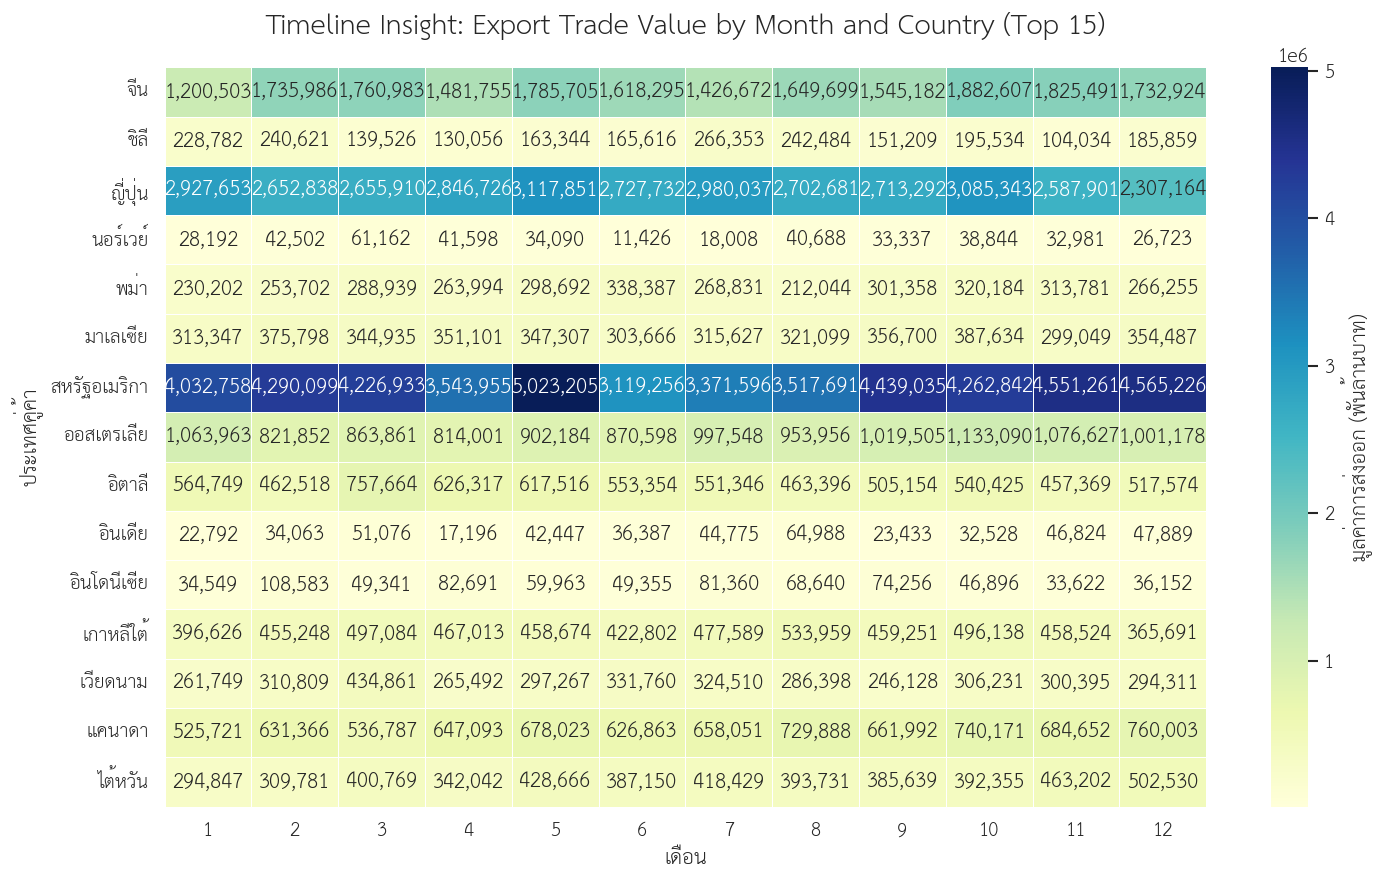

In [ ]:
# 3. Visualization: Heatmap for Export Trade Value
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_export_data / 1e3, # ปรับหน่วยเป็นพันล้านบาท
    cmap='YlGnBu',
    annot=True,
    fmt=",.0f",
    linewidths=0.5,
    cbar_kws={'label': 'มูลค่าการส่งออก (พันล้านบาท)'}
)

plt.title('Timeline Insight: Export Trade Value by Month and Country (Top 15)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('เดือน', fontsize=12)
plt.ylabel('ประเทศคู่ค้า', fontsize=12)
plt.xticks(rotation=0)
plt.show()

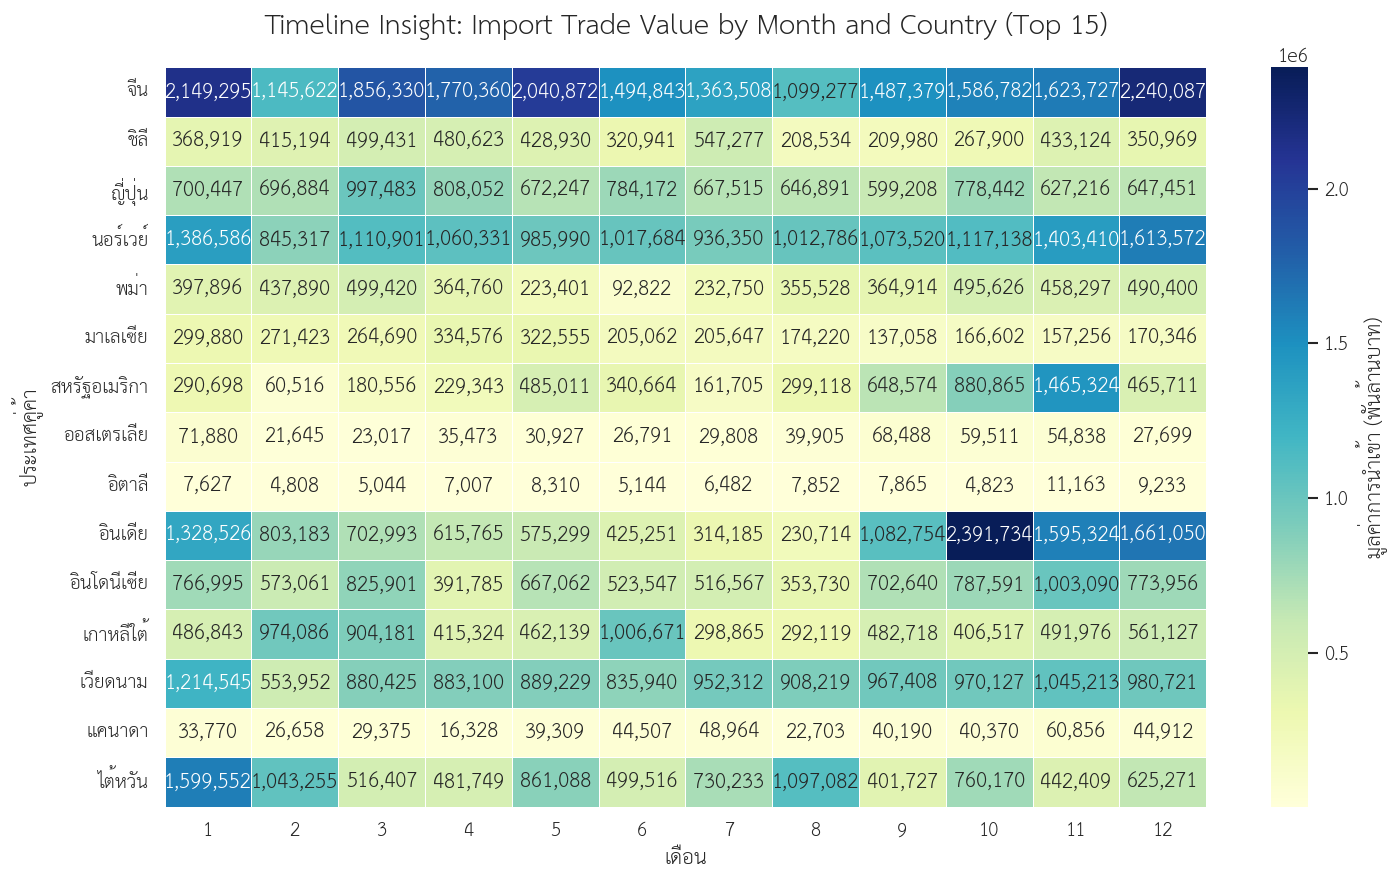

In [ ]:
# 2. Visualization: Heatmap for Import Trade Value
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_import_data / 1e3, # ปรับหน่วยเป็นพันล้านบาท
    cmap='YlGnBu',
    annot=True,
    fmt=",.0f",
    linewidths=0.5,
    cbar_kws={'label': 'มูลค่าการนำเข้า (พันล้านบาท)'}
)

plt.title('Timeline Insight: Import Trade Value by Month and Country (Top 15)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('เดือน', fontsize=12)
plt.ylabel('ประเทศคู่ค้า', fontsize=12)
plt.xticks(rotation=0)
plt.show()

วิเคราะห์ Insight จาก Timeline:

ความต้องการในตลาดจากคู่ค้า ต้องดูที่การส่งออก
1. ตลาดที่มีความสม่ำเสมอ: ดูจากแถวที่มีสีเข้มต่อเนื่องตลอดทั้งปี เช่น ญี่ปุ่น และหลายประเทศที่มีสีเหลืองอ่อน
2. ตลาดที่มีฤดูกาลชัดเจน: ดูจากเดือนที่มีสีเข้มโดดขึ้นมา คือ อเมริกา ทั้งต้นปี กลางปี ท้ายปี บ่งยอกถึงกำลังซื้อจำนวนมาก

ส่วนความต้องการในไทย จะดูจากการนำเข้า
1. ความต้องการช่วงต้นปี และปลายปี: การนำเข้าสูงขึ้นอย่างเห็นได้ชัดในช่วงต้นปี จากหลายประเทศ เช่น นอร์เวย์ และ จีน ส่วนต้นปีอย่างเดียว เช่น ไต้หวัน

ซึ่งเป็นการเตรียมวัตถุดิบเพื่อรองรับการผลิตและบริโภคที่เพิ่มขึ้นในช่วงเทศกาลปีใหม่ หรือสำหรับโรงงานแปรรูปในประเทศ

2. ความต้องการช่วงเดือนตุลาคม จากอินเดีย (ปลาหมึกกล้วยแช่แข็ง) จะสูงขึ้นอีกครั้งในช่วงเดือน 10-11 (ตุลาคม-พฤศจิกายน) ซึ่งเป็นไปตามที่ได้วิเคราะห์ไว้ก่อนหน้าว่าเป็นการเตรียมสต็อกสำหรับช่วงเทศกาลเฉลิมฉลองปลายปี และความต้องการที่เพิ่มขึ้นในตลาดภายในประเทศ

---
## 5️⃣ Dashboard Preparation 📊

### เตรียมข้อมูลสำหรับ Dashboard

ก่อนสร้าง Dashboard จริง เราต้อง **pre-aggregate** ข้อมูลให้อยู่ในรูปที่ dashboard engine (เช่น Power BI, Tableau, Looker Studio) สามารถใช้งานได้อย่างมีประสิทธิภาพ เราสร้าง summary tables หลายระดับ: ระดับประเทศ, จังหวัด, ประเภทสถาบัน, คณะ และระดับการศึกษา พร้อม export เป็น CSV และสร้าง combined dashboard ด้วย Plotly

In [ ]:
# Export ไฟล์เดียวสำหรับ Looker Studio

cleaned_df.to_csv('looker_fisheries.csv', index=False, encoding='utf-8-sig')

print('✅ Export สำเร็จ!')
import os
size_mb = os.path.getsize('looker_fisheries.csv') / 1024 / 1024
print(f'📄 looker_fisheries.csv ({size_mb:.1f} MB)')
print(f'📊 {len(cleaned_df):,} rows × {len(cleaned_df.columns)} columns')
print(f'🗂️  columns: {list(cleaned_df.columns)}')

✅ Export สำเร็จ!
📄 looker_fisheries.csv (11.3 MB)
📊 42,024 rows × 13 columns
🗂️  columns: ['year', 'month', 'heading11', 'countryID', 'countryNameTH', 'weight', 'quantity', 'price', 'tradeflow', 'productDetailEN', 'productDetailTH', 'ETL_DATE', 'Category']


### 🖥️ Interactive Dashboard (Plotly)

สุดท้ายเราสร้าง multi-panel dashboard ด้วย Plotly เพื่อแสดง KPI และ visualizations หลักทั้งหมดในหน้าเดียว ซึ่งสามารถ share เป็น HTML ได้ทันที Dashboard นี้จะรวม panels ต่างๆ เช่น: KPI cards แสดงมูลค่ารวมการค้า, กราฟแสดงคู่ค้าหลักทั้งนำเข้าและส่งออก, กราฟแสดงสินค้าหลักที่นำเข้าและส่งออก และกราฟแนวโน้มการค้าตามฤดูกาล

In [ ]:
# สร้าง Interactive Dashboard สำหรับข้อมูลประมงแบบรวมทุกการวิเคราะห์หลัก

# --- 0. เตรียมข้อมูล ---
# ข้อมูลรายประเทศและดุลการค้า
imports_by_country = cleaned_df[cleaned_df['tradeflow'] == 1].groupby(['countryID', 'countryNameTH'])['price'].sum().reset_index()
exports_by_country = cleaned_df[cleaned_df['tradeflow'] == 2].groupby(['countryID', 'countryNameTH'])['price'].sum().reset_index()
trade_summary = pd.merge(exports_by_country, imports_by_country, on=['countryID', 'countryNameTH'], how='outer', suffixes=('_Export', '_Import')).fillna(0)
trade_summary = trade_summary.rename(columns={'price_Export': 'Export_Value', 'price_Import': 'Import_Value'})
trade_summary['Trade_Balance'] = trade_summary['Export_Value'] - trade_summary['Import_Value']

# ข้อมูลรายเดือน
monthly_trade = cleaned_df.groupby(['month', 'tradeflow'])['price'].sum().unstack(fill_value=0).reset_index()
monthly_trade.columns = ['Month', 'Import', 'Export']
monthly_trade['Balance'] = monthly_trade['Export'] - monthly_trade['Import']

# ข้อมูลกลุ่มสินค้า (Category)
def categorize_product(name):
    name = str(name)
    if ('มีชีวิต' in name or 'สำหรับทำพันธุ์' in name) and 'ไม่มีชีวิต' not in name: return 'มีชีวิต'
    if 'หมึก' in name: return 'กลุ่มหมึก'
    if 'ปลา' in name and ('แช่เย็นจนแข็ง' in name or 'แช่แข็ง' in name): return 'กลุ่มปลา (แช่แข็ง)'
    if 'ปลา' in name and 'น้ำปลา' not in name: return 'กลุ่มปลา'
    if ('กุ้ง' in name or 'ลอบสเตอร์' in name or 'ล็อบเสตอร์' in name) and ('แช่เย็นจนแข็ง' in name or 'แช่แข็ง' in name): return 'กลุ่มกุ้ง (แช่แข็ง)'
    if 'กุ้ง' in name or 'ลอบสเตอร์' in name or 'ล็อบเสตอร์' in name: return 'กลุ่มกุ้ง'
    return 'อื่นๆ'

cleaned_df['Category'] = cleaned_df['productDetailTH'].apply(categorize_product)
net_cat = cleaned_df.groupby(['Category', 'tradeflow'])['price'].sum().unstack(fill_value=0)
net_cat['Net_Value'] = net_cat.get(2, 0) - net_cat.get(1, 0)
net_cat = net_cat.reset_index().sort_values('Net_Value', ascending=True)

# --- 1. สร้าง Dashboard ด้วย Subplots ---
fig = make_subplots(
    rows=4, cols=2,
    subplot_titles=[
        'Top 5 Import Sources', 'Top 5 Export Markets',
        'Top 5 Net Import Products', 'Top 5 Net Export Products',
        'Net Trade by Product Category', 'Fishery Trade Trends & Balance (Monthly)'
    ],
    specs=[
        [{}, {}],
        [{}, {}],
        [{'colspan': 2}, None],
        [{'colspan': 2}, None]
    ],
    vertical_spacing=0.08, horizontal_spacing=0.1
)

# 1. Top Countries (แถว 1)
top_exp = trade_summary.nlargest(5, 'Export_Value').sort_values('Export_Value', ascending=True)
top_imp = trade_summary.nlargest(5, 'Import_Value').sort_values('Import_Value', ascending=True)
fig.add_trace(go.Bar(x=top_imp['Import_Value'], y=top_imp['countryNameTH'], orientation='h', marker_color='#EF553B', name='Import Value'), row=1, col=1)
fig.add_trace(go.Bar(x=top_exp['Export_Value'], y=top_exp['countryNameTH'], orientation='h', marker_color='#636EFA', name='Export Value'), row=1, col=2)

# 2. Top Products (แถว 2)
product_trade_raw = cleaned_df.groupby(['productDetailTH', 'tradeflow'])['price'].sum().unstack(fill_value=0)
product_trade = product_trade_raw.reset_index()
product_trade.columns = ['Product_Name', 'Import', 'Export']
product_trade['Balance'] = product_trade['Export'] - product_trade['Import']
product_trade['Short_Name'] = product_trade['Product_Name'].apply(lambda x: x[:20] + '...' if len(x) > 20 else x)

top_net_exp = product_trade.nlargest(5, 'Balance').sort_values('Balance', ascending=True)
top_net_imp = product_trade.nsmallest(5, 'Balance').sort_values('Balance', ascending=False)
fig.add_trace(go.Bar(x=top_net_imp['Balance'], y=top_net_imp['Short_Name'], orientation='h', marker_color='red', hovertext=top_net_imp['Product_Name'], name='Net Import'), row=2, col=1)
fig.add_trace(go.Bar(x=top_net_exp['Balance'], y=top_net_exp['Short_Name'], orientation='h', marker_color='green', hovertext=top_net_exp['Product_Name'], name='Net Export'), row=2, col=2)

# 3. Net Category (แถว 3 - Full Width)
fig.add_trace(go.Bar(x=net_cat['Net_Value'], y=net_cat['Category'], orientation='h', marker_color='teal', name='Net Value Cat'), row=3, col=1)

# 4. Trends (แถว 4 - Full Width)
fig.add_trace(go.Scatter(x=monthly_trade['Month'], y=monthly_trade['Export'], name='Export Trend', line=dict(color='#636EFA')), row=4, col=1)
fig.add_trace(go.Scatter(x=monthly_trade['Month'], y=monthly_trade['Import'], name='Import Trend', line=dict(color='#EF553B')), row=4, col=1)
fig.add_trace(go.Scatter(x=monthly_trade['Month'], y=monthly_trade['Balance'], name='Balance Trend', line=dict(color='#FFCC00', dash='dash')), row=4, col=1)

fig.update_layout(height=1600, title_text="<b>Thailand Fishery Comprehensive Dashboard 2568</b>", title_x=0.5, showlegend=True)
fig.show()

fig.write_html('fishery_dashboard_comprehensive.html')

## 📝 สรุป Key Insights ที่ค้นพบ

---

สรุปภาพรวมการวิเคราะห์ข้อมูลนำเข้า-ส่งออกสินค้าประมงไทย ปี 2568:

1.  **ภาพรวมมูลค่า:** ประเทศไทยมีการค้ารวมกว่า 3.7 แสนล้านล้านบาท โดยได้เปรียบดุลการค้าสุทธิประมาณ 7 หมื่นล้านล้านบาท (ส่งออก 59% / นำเข้า 41%)

2.  **คู่ค้าเชิงยุทธศาสตร์:**
    *   ตลาดส่งออกหลักคือ **สหรัฐอเมริกา** และ **ญี่ปุ่น**
    
    เป็นตลาดหลักที่มีความต้องการสินค้าประมงแปรรูปจากไทยอย่างสม่ำเสมอตลอดทั้งปี

    *   ส่วนแหล่งนำเข้าหลักคือ **จีน** และ **นอร์เวย์**

    เป็นแหล่งวัตถุดิบต้นน้ำที่สำคัญ โดยเฉพาะปลาพรีเมียมอย่างแซลมอนจากนอร์เวย์

3.  **ห่วงโซ่อุปทาน (Supply Chain):** จากข้อมูล **ดุลการค้า** ไทยทำหน้าที่เป็น 'Global Processing Hub' อย่างชัดเจน โดยนำเข้าวัตถุดิบและพ่อแม่พันธุ์จากกลุ่มประเทศขาดดุล (นอร์เวย์, อินเดีย, เวียดนาม) มาสร้างมูลค่าเพิ่มและส่งออกไปยังตลาดที่มีกำลังซื้อสูง (สหรัฐฯ, ญี่ปุ่น, ออสเตรเลีย) ที่เกินดุลการค้า

4.  **สินค้าประมงชนิดใดคือหัวใจของการค้าไทย?:**

- สินค้าส่งออกมากกว่านำเข้า (Net Export): 'ปลาทูน่าแปรรูป' และ 'อาหารสัตว์เลี้ยงที่มีปลา' คือสินค้าชูโรงที่สร้างรายได้มหาศาลและมีศักยภาพในตลาดโลก
- สินค้าที่ต้องพึ่งพาการนำเข้า (Net Import): 'ปลาแช่แข็ง' (เช่น ทูน่าแช่แข็ง, ปลาหมึก) และปลาพรีเมียม (แซลมอน) ซึ่งใช้เป็นวัตถุดิบหลักในอุตสาหกรรมแปรรูป

    และกลุ่มปลาครองปริมาณมหาศาล (High Volume) ในขณะที่กลุ่ม 'มีชีวิต' และ 'คาร์เวีย' เป็นกลุ่มทำกำไรสูงต่อหน่วย (High Margin)

5.  **ปัจจัยฤดูกาล:**
    - ช่วงการค้าสูงสุด (Peak):
    ส่งออก: พีคที่สุดในเดือนพฤษภาคม (ประมาณ 2 หมื่นล้านล้านบาท) คาดว่าเป็นช่วงที่ผลผลิตสัตว์น้ำเศรษฐกิจเข้าสู่โรงงานมากที่สุด
    นำเข้า: พีคในช่วงมกราคม และตุลาคม-พฤศจิกายน เพื่อเตรียมสต็อกสำหรับเทศกาลปีใหม่

    - ช่วงการค้าต่ำสุด (Low):
    ส่งออก: ต่ำสุดในเดือนมิถุนายน อาจมาจากปัจจัยสภาพอากาศมรสุมหรือการแข่งขันในตลาดต่างประเทศ
    นำเข้า: ต่ำสุดในเดือนสิงหาคม

    - สมมติฐาน: รูปแบบนี้เกิดจาก 'Festive Season' (ความต้องการบริโภคช่วงเทศกาล) และบทบาทของไทยที่เป็น 'Global Processing Hub' ซึ่งต้องนำเข้าวัตถุดิบมาสำรองล่วงหน้าเพื่อแปรรูปและส่งออกตามความต้องการของตลาดโลก

6.  **มูลค่าต่อหน่วย (Unit Value) ของสินค้าหลักในประเทศคู่ค้าต่างๆ:**
    *   **ปลาแซลมอนแอตแลนติก สด แช่เย็น:** มูลค่าสูงสุดจากญี่ปุ่น (810.97 ล้านบาท/1,000 กก.) และต่ำสุดจากการส่งออกไปบังคลาเทศ (92.62 ล้านบาท/1,000 กก.) แสดงถึงความหลากหลายด้านคุณภาพและราคาในตลาดโลก
    *   **ปลาทูน่า สคิปแจกและแอตแลนติกโบนิโตอื่นๆ ที่บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้:** มีความแตกต่างของมูลค่าต่อหน่วยสูงมากถึง 144.38 เท่า ระหว่างการนำเข้าจากอียิปต์ (4,620 ล้านบาท/1,000 กก.) และการส่งออกไปโครเอเชีย (32 ล้านบาท/1,000 กก.) ชี้ให้เห็นถึงความแตกต่างของคุณลักษณะสินค้าหรือกำลังซื้อของตลาด
    *   **อาหารสุนัขหรือแมวที่มีปลาบรรจุภาชนะที่อากาศเข้าออกไม่ได้:** มูลค่าต่อหน่วยสูงสุดจากการนำเข้าจากฟิลิปปินส์ (1,291 ล้านบาท/1,000 กก.) และต่ำสุดจากการส่งออกไปเคนยา (53.74 ล้านบาท/1,000 กก.) สะท้อนถึงสินค้าพรีเมียมกับการแข่งขันด้านราคา
    *   **ปลาหมึกกล้วย แช่เย็นจนแข็ง:** นำเข้าจากสเปนมีมูลค่าสูง (1,070.50 ล้านบาท/1,000 กก.) เทียบกับพม่าที่มีมูลค่าต่ำ (25.19 ล้านบาท/1,000 กก.) บ่งบอกถึงความหลากหลายของสายพันธุ์หรือคุณภาพวัตถุดิบ

ข้อมูลนี้เน้นย้ำว่าไทยเป็นศูนย์กลางการแปรรูปสินค้าประมงที่สำคัญ โดยมีการนำเข้าวัตถุดิบและส่งออกสินค้าแปรรูปที่มีมูลค่าเพิ่มสูง การทำความเข้าใจความแตกต่างของมูลค่าต่อหน่วยในแต่ละคู่ค้าและผลิตภัณฑ์จะเป็นประโยชน์ในการกำหนดกลยุทธ์การค้าและการเพิ่มขีดความสามารถในการแข่งขันของไทยในตลาดโลก